In [55]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns
from pathlib import Path

# coastsat modules
sys.path.insert(0, os.pardir)
from coastsat import SDS_tools, SDS_preprocess
from osgeo import gdal
gdal.UseExceptions()

from general_utils.indices import *
from general_utils.thresholding import *
from general_utils import (
    spectral_unmixing as su,
    metrics as m,
    modified_coastsat
)

from wv3_utils import (
    wv_utils as wv,
    wv_eval,
    wv_eval_plotting as wvep,
    degradation as deg,
    local_sl_extraction as lse
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
# paths
# base_dir = "C:\\Users\\avanever\\Documents\\Imagery Datasets\\WV3 SWIR\\W075_N10\\20200104T15431"
# swir_fn = os.path.join(base_dir, "20JAN04154316-A3DS-015384188020_01_P001.TIF")
# ms_fn = os.path.join(base_dir, "20JAN04154317-M3DS-015384188010_01_P001.TIF")
# pan_fn = os.path.join(base_dir, "20JAN04154317-P3DS-015384188010_01_P001.TIF")
# ref_sl_path = Path(r"C:\Users\avanever\Documents\CoastSatProject\Experiments\data\colombia_hand_digitized\colombia_hand_shoreline.shp")
# transect_path = Path(r"C:\Users\avanever\Documents\CoastSatProject\Experiments\data\transects\colombia_transects.geojson")
# ref_sl_path = Path(r"C:\Users\avanever\Documents\CoastSatProject\Experiments\data\colombia_hand_digitized\colombia_hand_shoreline.shp")
base_dir = r"C:\Users\avanever\Documents\HaidaGwaiiData\WV3"
swir_fn = os.path.join(base_dir, "Haida_Gwaii_SWIR.tif")
ms_fn = os.path.join(base_dir, "Haida_Gwaii_MS_Merged.tif")
pan_fn = os.path.join(base_dir, "Haida_Gwaii_Pan_Merged.tif")
ref_sl_path = Path(r"C:\Users\avanever\Documents\HaidaGwaiiData\shoreline_3155.shp")
transect_path = Path(r"C:\Users\avanever\Documents\HaidaGwaiiData\rennell-sound_transects.geojson")

im_dir = r"C:\Users\avanever\Documents\HaidaGwaiiData\sim_imagery\\"

# initialization
# sitename = "Colombia"
# image_epsg = 32618
sitename="HaidaGwaii"
image_epsg = 3155

## Degradation

Using Gaussian kernel for degradation (with FWHM modified scale)

L5:
- Degrade to 30m
- Bilinear interpolation to 15m
- SNR Match

L7:
- Degrade ms to 30m and pan to 15m
- Pansharpening (still bands 0, 1, 2 cuz that's what's covered by WV3)
- SNR Match

L8 and L9:
- Degrade ms to 30m and pan to 15m
- Pansharpening (bands 0, 1, 2)

S2:
- Degrade ms to 10m and swir to 20m
- Bilinear interpolation to 10m

In [83]:
# l8_path = r"C:\Users\avanever\Documents\CoastSatProject\Experiments\data\colombia\L8\ms\2020-01-09-15-17-31_L8_009053_colombia_ms.tif"
# l9_path = r"C:\Users\avanever\Documents\CoastSatProject\Experiments\data\colombia\L9\ms\2021-12-28-15-23-48_L9_010053_colombia_ms.tif"
# s2_path = r"C:\Users\avanever\Documents\CoastSatProject\Experiments\data\colombia\S2\2020-01-02-15-40-10_S2_18PVS_colombia.tif"
l8_path = r"C:\Users\avanever\Documents\Experiments\Data\rennell-sound\L8\ms\2013-08-03-19-51-41_L8_055023_rennell-sound_ms.tif"
l9_path = r"C:\Users\avanever\Documents\Experiments\Data\rennell-sound\L9\ms\2022-07-28-19-43-31_L9_054023_rennell-sound_ms.tif"
s2_path = r"C:\Users\avanever\Documents\Experiments\Data\rennell-sound\S2\2017-08-09-20-06-35_S2_08UPE_rennell-sound.tif"
l8_bands = wv.load_sim_tif(l8_path)
l9_bands = wv.load_sim_tif(l9_path)
s2_bands = wv.load_sim_tif(s2_path)

out_fns = {sat : im_dir + sat + "_sim.tif" for sat in ["L8", "L9", "S2"]}
ref_fn = [l8_path, l9_path, s2_path]

deg_30_fn = im_dir + "deg_30.tif"
warp_fn = im_dir + "ms_interp_15.tif"
ps_fn = im_dir + "ps_15.tif"
swir_warp_fn = im_dir + "swir_interp_10.tif"
deg_20_fn = im_dir + "swir_deg_15.tif"

In [103]:
ms_10_output[0,-1,:]

array([nan, nan, nan, nan])

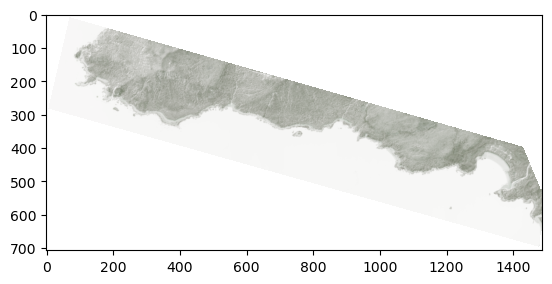

In [102]:
plt.imshow(ms_10_output)

In [96]:
# get source bands coregistered and in swir's resolution
coreg_swir_fn, coreg_pan_fn, coreg_ms_fn = wv.coreg_tifs(base_dir, gdal.GRA_Bilinear, fns=[swir_fn, pan_fn, ms_fn], ref_idx=0) # use swir as reference for coreg
swir_bands = wv.load_tif(coreg_swir_fn, is_swir=True)[:,:,[1, 5]]
ms_bands = wv.load_tif(coreg_ms_fn)[:,:,[1, 2, 4, 6]]
pan_band = wv.load_tif(coreg_pan_fn)
ms_ds = gdal.Open(coreg_ms_fn)
in_gt, in_proj = ms_ds.GetGeoTransform(), ms_ds.GetProjection()
ms_ds = None
source_bands = np.concatenate([ms_bands, swir_bands], axis=2)
source_res = 7.5 # SET TO RESOLUTION OF SWIR BANDS
kernel_radius = 12

""" Gaussian Kernel Degradation """
ms_30_output, ms_30_adj_res, _ = deg.kernel_deg(source_bands, source_res, kernel_radius, target_res=30) # all Landsat
pan_output, pan_adj_res, _ = deg.kernel_deg(pan_band, source_res, kernel_radius, target_res=15) # L7, L8, L9
ms_10_output, ms_10_adj_res, _ = deg.kernel_deg(ms_bands, source_res, kernel_radius, target_res=10) # S2
swir_output, swir_adj_res, _ = deg.kernel_deg(swir_bands, source_res, kernel_radius, target_res=ms_10_adj_res * 2) # S2

""" Pansharpening (L7, L8, L9) """
deg.save_gaus_deg_tif(deg_30_fn, ms_30_output, source_res, kernel_radius, ms_30_adj_res, in_proj, in_gt)
bounds = deg.calc_bounds(source_res, kernel_radius, ms_30_adj_res, ms_30_output.shape, in_gt)
deg.double_resolution(warp_fn, deg_30_fn, ms_30_adj_res, bounds)
im_ms_ps = deg.pansharpen_gaussian_deg(warp_fn, pan_output)
deg.save_ps_tif(ps_fn, im_ms_ps, bounds, ms_30_adj_res, in_proj)

""" Double resolution swir 20m bands """
deg.save_gaus_deg_tif(deg_20_fn, swir_output, source_res, kernel_radius, swir_adj_res, in_proj, in_gt)
bounds = deg.calc_bounds(source_res, kernel_radius, swir_adj_res, swir_output.shape, in_gt)
deg.double_resolution(swir_warp_fn, deg_20_fn, swir_adj_res, bounds)
swir_10_output = wv.load_sim_tif(swir_warp_fn)
ms_10_output, swir_10_output = deg.normalize_im_dim([ms_10_output, swir_10_output])
deg_10_bands = np.concatenate([ms_10_output, swir_10_output], axis=2)

3762018
625588
2503208
1258810


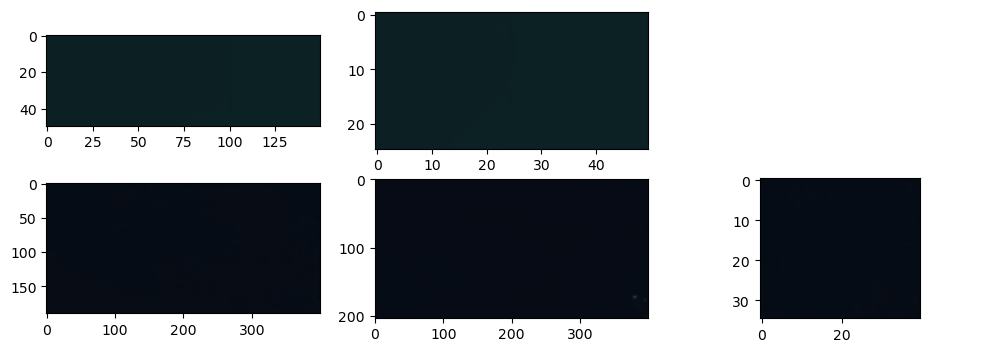

In [93]:
""" Confirm Patches are good for SNR Matching"""
# Colombia
l8_patch, l9_patch, s2_patch = l8_bands[100:120,70:85], l9_bands[100:120,70:85], s2_bands[155:190,95:135]
patch_indices = {
    "S2" : {"r": (40,53), "c": (10,30)}, # gs_deg_10
    "L_PS" : {"r": (32,40), "c": (10,25)}, # gs_ps_15
}

# Haida Gwaii
l8_patch, l9_patch, s2_patch = l8_bands[200:-10,:400], l9_bands[200:-10,:400], s2_bands[155:190,95:135]
patch_indices = {
    "S2" : {"r": (350,400), "c": (450,600)}, # gs_deg_10
    "L_PS" : {"r": (175,200), "c": (250,300)}, # gs_ps_15
}

p = patch_indices["S2"]
s2_sim_patch = deg_10_bands[p["r"][0]:p["r"][1], p["c"][0]:p["c"][1]]
p = patch_indices["L_PS"]
l_ps_sim_patch = im_ms_ps[p["r"][0]:p["r"][1], p["c"][0]:p["c"][1]]

fig, axs = plt.subplots(2, 3, figsize=(12, 4))
axs = axs.ravel()
axs[0].imshow(s2_sim_patch[:,:,[2,1,0]])
axs[1].imshow(l_ps_sim_patch[:,:,[2,1,0]])
axs[2].axis(False); # for L5

axs[3].imshow(l8_patch[:,:,[2,1,0]])
axs[4].imshow(l9_patch[:,:,[2,1,0]])
axs[5].imshow(s2_patch[:,:,[2,1,0]])

In [94]:
""" SNR Matching """
s2_snr, _, _ = deg.directional_semivariogram_snr(s2_patch, dir="row")
l8_snr, _, _ = deg.directional_semivariogram_snr(l8_patch, dir="row")
l9_snr, _, _ = deg.directional_semivariogram_snr(l9_patch, dir="row")

s2_sim_snr, _, _,  = deg.directional_semivariogram_snr(s2_sim_patch, dir="row")
l_ps_sim_snr, _, _,  = deg.directional_semivariogram_snr(l_ps_sim_patch, dir="row")

l8_sim = deg.match_snr(im_ms_ps, l_ps_sim_snr, l8_snr)
l9_sim = deg.match_snr(im_ms_ps, l_ps_sim_snr, l9_snr)
s2_sim = deg.match_snr(deg_10_bands, s2_sim_snr, s2_snr)

""" Save final simulation images"""
deg.save_gaus_deg_tif(out_fns["L8"], l8_sim, source_res, kernel_radius, pan_adj_res, in_proj, in_gt)
deg.save_gaus_deg_tif(out_fns["L9"], l9_sim, source_res, kernel_radius, pan_adj_res, in_proj, in_gt)
deg.save_gaus_deg_tif(out_fns["S2"], s2_sim, source_res, kernel_radius, ms_10_adj_res, in_proj, in_gt)

33 transects have been loaded 
coordinates are in epsg:3155


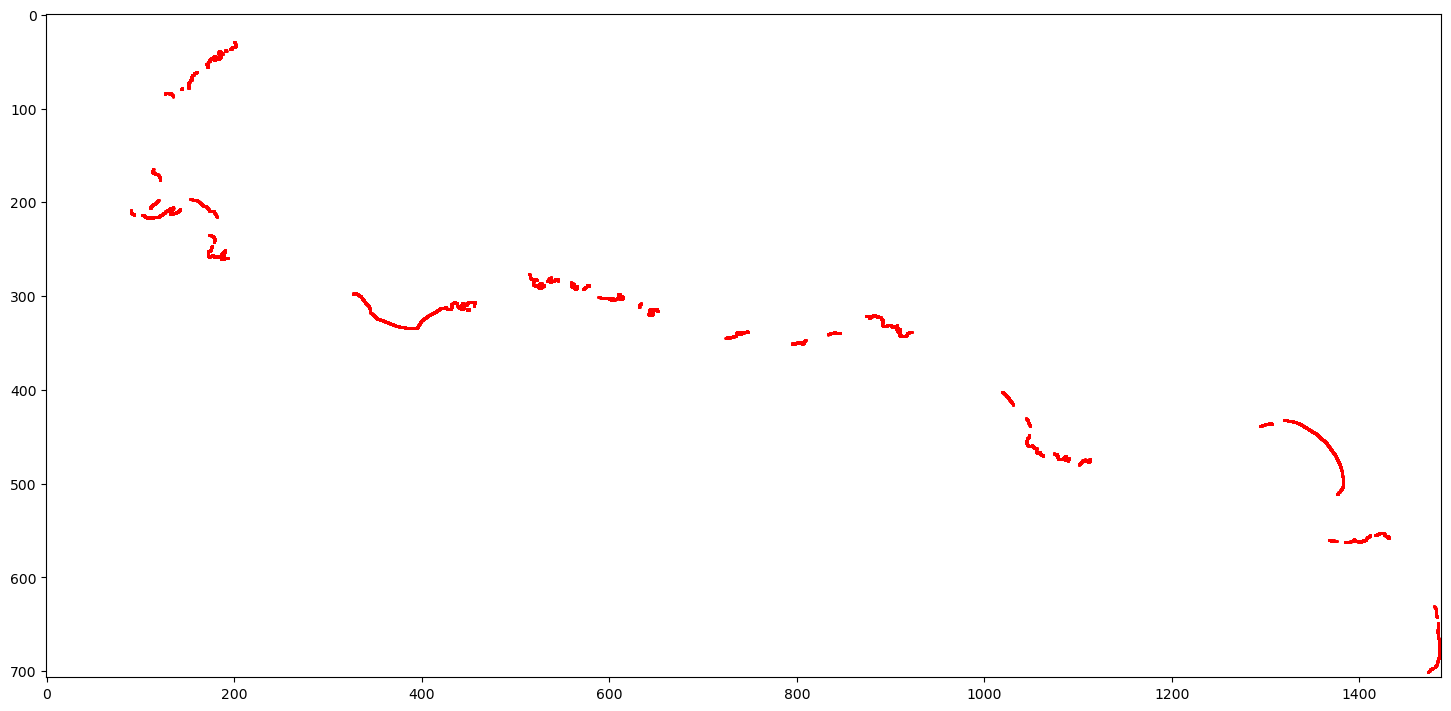

In [95]:
sim_sat = "S2"
fig, ax = plt.subplots(figsize=(18, 10))

fn = out_fns[sim_sat]
bands = wv.load_sim_tif(fn)
ax.imshow(SDS_preprocess.rescale_image_intensity(bands[:,:,[2,1,0]], np.zeros(bands.shape[:2]).astype(bool), 99.9))


gt = gdal.Open(fn).GetGeoTransform()
sl_px = wv.init(sim_sat, im_dir, ref_sl_path, transect_path, image_epsg)[7]
# sl_px = modified_coastsat.convert_world2pix(ref_sl_points, gt)
ax.scatter(sl_px[:,0], sl_px[:,1], s=1, c="red")

## Save Plots

In [78]:
sim_sat = "S2"

data = wv.init(sim_sat, im_dir, ref_sl_path, transect_path, image_epsg)
sim_bands, georef, im_nodata, cloud_mask, transects, transects_pix, ref_sl_points, ref_sl_points_pxl, sds_settings, collider_settings, sds_data = data

index_functions = [
    mndwi,
    ndwi,
    awei_ns,
    awei_sh,
    scowi,
    wi2015,
    andwi,
    wri,
    ewi,
    nwi,
    wi2019,
    tct_wetness,
    ddwi,
    ens1,
    ens2,
    "su1",
    "su2",
]
threshold_functions = [
    otsu,
    lmo
]
ensemble_idx_funcs = get_ensemble_list() # all but the ensemble indices and spectral unmixing

33 transects have been loaded 
coordinates are in epsg:3155


In [79]:
sitename = "Haida Gwaii"

# root_output_dir = os.path.join(r"C:\Users\avanever\Documents\CoastSatProject\Experiments\wv3", sitename)
root_output_dir = os.path.join(r"C:\Users\avanever\Documents\Experiments\wv3", sitename)

# sim_sats = ["L8", "L9", "S2"]
sim_sats = ["S2"]
image_epsg = 3155

for sim_sat in sim_sats:
    output_dir = os.path.join(root_output_dir, sim_sat)
    os.makedirs(output_dir, exist_ok=True)

    data = wv.init(sim_sat, im_dir, ref_sl_path, transect_path, image_epsg)
    sim_bands, georef, im_nodata, cloud_mask, transects, transects_pix, ref_sl_points, ref_sl_points_pxl, sds_settings, collider_settings, sds_data = data
    im_rgb = SDS_preprocess.rescale_image_intensity(sim_bands[:,:,[2,1,0]], np.zeros(sim_bands.shape[:2]).astype(bool), 99.9)

    """ Run All Methods """
    shoreline_metric, transect_metric, methods, info = wv_eval.evaluate_methods(
        index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs
    )
    entries, outlier_idx = wv_eval.organize_metrics(shoreline_metric, transect_metric, methods)

    sl_values = np.nanmin(shoreline_metric, axis=0)
    best_per_point_idx = np.nanargmin(shoreline_metric, axis=0)

    best_per_transect_idx = np.nanargmin(np.abs(transect_metric), axis=0)
    t_idx = np.arange(transect_metric.shape[1])
    t_values = np.abs(transect_metric[best_per_transect_idx, t_idx])

    """ Save metrics for each method to text file """
    with open(os.path.join(output_dir, "metrics.txt"), 'w') as f:
        wv_eval.print_metrics(entries, sort_variable="sl_mean", file=f)
        print("\n\n", file=f)
        wv_eval.print_metrics(entries, sort_variable="t_mae", file=f)
        print("\n\n", file=f)
        wv_eval.print_metrics(entries, sort_variable="sl_n_outliers", file=f)
        print("\n\n", file=f)
        wv_eval.print_metrics(entries, sort_variable="t_mean", file=f)
        print("\n\n", file=f)
        wv_eval.print_metrics(entries, sort_variable="sl_mean_all", file=f)

    """ 'Best per' plots """
    fig = wvep.plot_best_score_per_point(sl_values, ref_sl_points_pxl, im_rgb, sitename, sim_sat)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "_best_score_per_point"))
    plt.close(fig)
    fig = wvep.plot_best_method_per_point(best_per_point_idx, methods, ref_sl_points_pxl, im_rgb, sitename, sim_sat)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "_best_method_per_point"))
    plt.close(fig)
    fig = wvep.plot_best_method_counts(best_per_point_idx, methods, sim_sat + ": Shoreline Metric Best Method Percentages", pie_instead=True)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "_best_sl_method_pie"))
    plt.close(fig)
    fig = wvep.plot_best_score_per_transect(t_values, transects_pix, ref_sl_points_pxl, im_rgb, sitename, sim_sat)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "_best_score_per_transect"))
    plt.close(fig)
    fig = wvep.plot_best_method_per_transect(best_per_transect_idx, methods, transects_pix, ref_sl_points_pxl, im_rgb, sitename, sim_sat)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "_best_method_per_transect"))
    plt.close(fig)
    fig = wvep.plot_best_method_counts(best_per_transect_idx, methods, sim_sat + ": Transect Metric Best Method Percentages", pie_instead=True)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "_best_transect_method_pie"))
    plt.close(fig)

    """ Boxplots """
    title = f"{sitename}_{sim_sat}: Shoreline Metric Boxplot"
    fig, ax = wvep.violin_plots(shoreline_metric, methods, title, ylim=(0, 25), box_instead=True, sort_methods=True)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "_shoreline_metric_boxplot"))
    plt.close(fig)
    fig, ax = wvep.violin_plots(shoreline_metric, methods, title, box_instead=True, sort_methods=True)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "_shoreline_metric_boxplot_no_ylim"))
    plt.close(fig)
    title = f"{sitename}_{sim_sat}: Transect Metric Error Boxplot"
    fig, ax = wvep.violin_plots(transect_metric, methods, title, box_instead=True, sort_methods=True)
    ax.axhline(0)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "_transect_error_boxplot"))
    plt.close(fig)
    title = f"{sitename}_{sim_sat}: Transect Metric Absolute Error Boxplot"
    fig, ax = wvep.violin_plots(np.abs(transect_metric), methods, title, box_instead=True, sort_methods=True)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "_transect_AE_boxplot"))
    plt.close(fig)

    """ Combinations of note """
    os.makedirs(os.path.join(output_dir, "combinations"), exist_ok=True)

    # Ensemble2 + Otsu
    index = ens2(sim_bands, ensemble_idx_funcs, otsu, cloud_mask, sds_data["sl_buffer"])
    threshold = otsu(index, cloud_mask, sds_data["sl_buffer"])
    method = "ensemble2__otsu"
    sl_fig, t_fig = wvep.plot_method(index, threshold, method, sim_bands, sds_data, ref_sl_points, ref_sl_points_pxl, transects, transects_pix, collider_settings, outlier_idx, georef, sitename, sim_sat)
    sl_fig.savefig(os.path.join(output_dir, "combinations", sitename + "_" + sim_sat + "_" + method + "_sl"))
    t_fig.savefig(os.path.join(output_dir, "combinations", sitename + "_" + sim_sat + "_" + method + "_t"))
    plt.close(sl_fig)
    plt.close(t_fig)

    # mndwi + otsu
    index = mndwi(sim_bands.reshape(-1, sim_bands.shape[-1]))
    threshold = otsu(index, cloud_mask, sds_data["sl_buffer"])
    method = "mndwi__otsu"
    sl_fig, t_fig = wvep.plot_method(index, threshold, method, sim_bands, sds_data, ref_sl_points, ref_sl_points_pxl, transects, transects_pix, collider_settings, outlier_idx, georef, sitename, sim_sat)
    sl_fig.savefig(os.path.join(output_dir, "combinations", sitename + "_" + sim_sat + "_" + method + "_sl"))
    t_fig.savefig(os.path.join(output_dir, "combinations", sitename + "_" + sim_sat + "_" + method + "_t"))
    plt.close(sl_fig)
    plt.close(t_fig)

    # ewi + otsu (second best)
    index = ewi(sim_bands.reshape(-1, sim_bands.shape[-1]))
    threshold = otsu(index, cloud_mask, sds_data["sl_buffer"])
    method = "ewi__otsu"
    sl_fig, t_fig = wvep.plot_method(index, threshold, method, sim_bands, sds_data, ref_sl_points, ref_sl_points_pxl, transects, transects_pix, collider_settings, outlier_idx, georef, sitename, sim_sat)
    sl_fig.savefig(os.path.join(output_dir, "combinations", sitename + "_" + sim_sat + "_" + method + "_sl"))
    t_fig.savefig(os.path.join(output_dir, "combinations", sitename + "_" + sim_sat + "_" + method + "_t"))
    plt.close(sl_fig)
    plt.close(t_fig)

    # spectral unmixing + otsu
    im_ind = ens2(sim_bands, ensemble_idx_funcs, otsu, cloud_mask, sds_data["sl_buffer"])
    percentages = su.spectral_unmixing_1(sim_bands, im_ind, sds_data)
    otsu_thresh = otsu(percentages, cloud_mask, sds_data["sl_buffer"])
    method = "spectral_unmixing_1__otsu"
    sl_fig, t_fig = wvep.plot_method(percentages, otsu_thresh, method, sim_bands, sds_data, ref_sl_points, ref_sl_points_pxl, transects, transects_pix, collider_settings, outlier_idx, georef, sitename, sim_sat)
    sl_fig.savefig(os.path.join(output_dir, "combinations", sitename + "_" + sim_sat + "_" + method + "_sl"))
    t_fig.savefig(os.path.join(output_dir, "combinations", sitename + "_" + sim_sat + "_" + method + "_t"))
    plt.close(sl_fig)
    plt.close(t_fig)
    
    # spectral unmixing + otsu
    im_ind = ens2(sim_bands, ensemble_idx_funcs, otsu, cloud_mask, sds_data["sl_buffer"])
    percentages = su.spectral_unmixing_2(sim_bands, im_ind, sds_data)
    percentages[percentages < 0.6] = np.nan
    otsu_thresh = otsu(percentages, cloud_mask, sds_data["sl_buffer"])
    method = "spectral_unmixing_2__otsu"
    sl_fig, t_fig = wvep.plot_method(percentages, otsu_thresh, method, sim_bands, sds_data, ref_sl_points, ref_sl_points_pxl, transects, transects_pix, collider_settings, outlier_idx, georef, sitename, sim_sat)
    sl_fig.savefig(os.path.join(output_dir, "combinations", sitename + "_" + sim_sat + "_" + method + "_sl"))
    t_fig.savefig(os.path.join(output_dir, "combinations", sitename + "_" + sim_sat + "_" + method + "_t"))
    plt.close(sl_fig)
    plt.close(t_fig)

    # tct_wetness + otsu (most amount of "best" points)
    index = tct_wetness(sim_bands.reshape(-1, sim_bands.shape[-1]))
    threshold = otsu(index, cloud_mask, sds_data["sl_buffer"])
    method = "tct_wetness__otsu"
    sl_fig, t_fig = wvep.plot_method(index, threshold, method, sim_bands, sds_data, ref_sl_points, ref_sl_points_pxl, transects, transects_pix, collider_settings, outlier_idx, georef, sitename, sim_sat)
    sl_fig.savefig(os.path.join(output_dir, "combinations", sitename + "_" + sim_sat + "_" + method + "_sl"))
    t_fig.savefig(os.path.join(output_dir, "combinations", sitename + "_" + sim_sat + "_" + method + "_t"))
    plt.close(sl_fig)
    plt.close(t_fig)

    """ Binarized indice comparison (test subpixel assumption) """
    bin_shoreline_metric, bin_transect_metric, methods, info = wv_eval.evaluate_methods(
        index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs, binarize=True
    )
    bin_entries, outlier_idx = wv_eval.organize_metrics(bin_shoreline_metric, bin_transect_metric, methods, outlier_idx)

    metrics = list(entries[0].keys())[1:]
    fig = wvep.plot_comparison(bin_entries, entries, "binarized", "interpolated", metrics)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "_binarized_index_comparison"))
    plt.close(fig)

    """ LSE """
    lse1_shoreline_metric, lse1_transect_metric, methods, info = wv_eval.evaluate_methods(
        index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs, lse1=True
    )
    lse2_shoreline_metric, lse2_transect_metric, methods, info = wv_eval.evaluate_methods(
        index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs, lse2=True
    )
    lse1_entries, _ = wv_eval.organize_metrics(lse1_shoreline_metric, lse1_transect_metric, methods, outlier_idx)
    lse2_entries, _ = wv_eval.organize_metrics(lse2_shoreline_metric, lse2_transect_metric, methods, outlier_idx)
    
    with open(os.path.join(output_dir, "LSE.txt"), 'w') as f:
        wv_eval.print_metrics(entries, sort_variable="sl_mean_all", file=f)
        print("\n\n", file=f)
        wv_eval.print_metrics(lse1_entries, sort_variable="sl_mean_all", file=f)
        print("\n\n", file=f)
        wv_eval.print_metrics(lse2_entries, sort_variable="sl_mean_all", file=f)
    
    entries_arr = [entries, lse1_entries, lse2_entries]
    titles = ["none", "lse1", "lse2"]
    plot_title = "LSE Relative Comparison"
    fig = wvep.plot_comparison_barplot(entries_arr, titles, plot_title)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "_LSE_relative_comparison"))
    plt.close(fig)

    metrics = list(entries[0].keys())[1:]
    fig = wvep.plot_comparison(lse1_entries, lse2_entries, "lse1", "lse2", metrics, sl_lim=100)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "_LSE_comparison"))
    plt.close(fig)

33 transects have been loaded 
coordinates are in epsg:3155


34it [00:29,  1.15it/s]
7it [00:05,  1.25it/s]


KeyboardInterrupt: 

## Bests for Shoreline Metric (nearest point) and Transect Metric (median distance)

Best method changes so frequently picking a "best" method is very ambiguous (beyond looking at summary metrics)

Some areas are not extracted well by any methods (around clouds, certain edges)

In [7]:
shoreline_metric, transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs
)
entries, outlier_idx = wv_eval.organize_metrics(shoreline_metric, transect_metric, methods)

sl_values = np.nanmin(shoreline_metric, axis=0)
best_per_point_idx = np.nanargmin(shoreline_metric, axis=0)

best_per_transect_idx = np.nanargmin(np.abs(transect_metric), axis=0)
t_idx = np.arange(transect_metric.shape[1])
t_values = np.abs(transect_metric[best_per_transect_idx, t_idx])

34it [00:12,  2.73it/s]


ValueError: All-NaN slice encountered

In [ ]:
wv_eval.print_metrics(entries, sort_variable="sl_mean")
print("\n")
wv_eval.print_metrics(entries, sort_variable="t_mae")
print("\n")
wv_eval.print_metrics(entries, sort_variable="sl_n_outliers")
print("\n")
wv_eval.print_metrics(entries, sort_variable="t_mean")

Sorted by sl_mean                   sl_mean      sl_mean_all  sl_std       sl_outlier     t_mean       t_std        t_mae       
spectral_unmixing_1__otsu:          4.793        8.351        13.374       1604           1.442        3.217        2.566       
ewi__otsu:                          4.882        10.335       18.628       1929           1.352        2.497        2.198       
ndwi__otsu:                         5.821        21.018       47.545       2610           -0.163       4.899        3.159       
ensemble1__otsu:                    5.946        22.889       46.776       3530           1.502        4.769        3.745       
ensemble2__otsu:                    6.003        22.231       45.834       3455           1.207        4.731        3.753       
andwi__otsu:                        6.437        23.266       46.358       3592           1.303        4.968        3.823       
ewi__local_min_otsu:                6.763        22.772       49.223       2901           2.576  

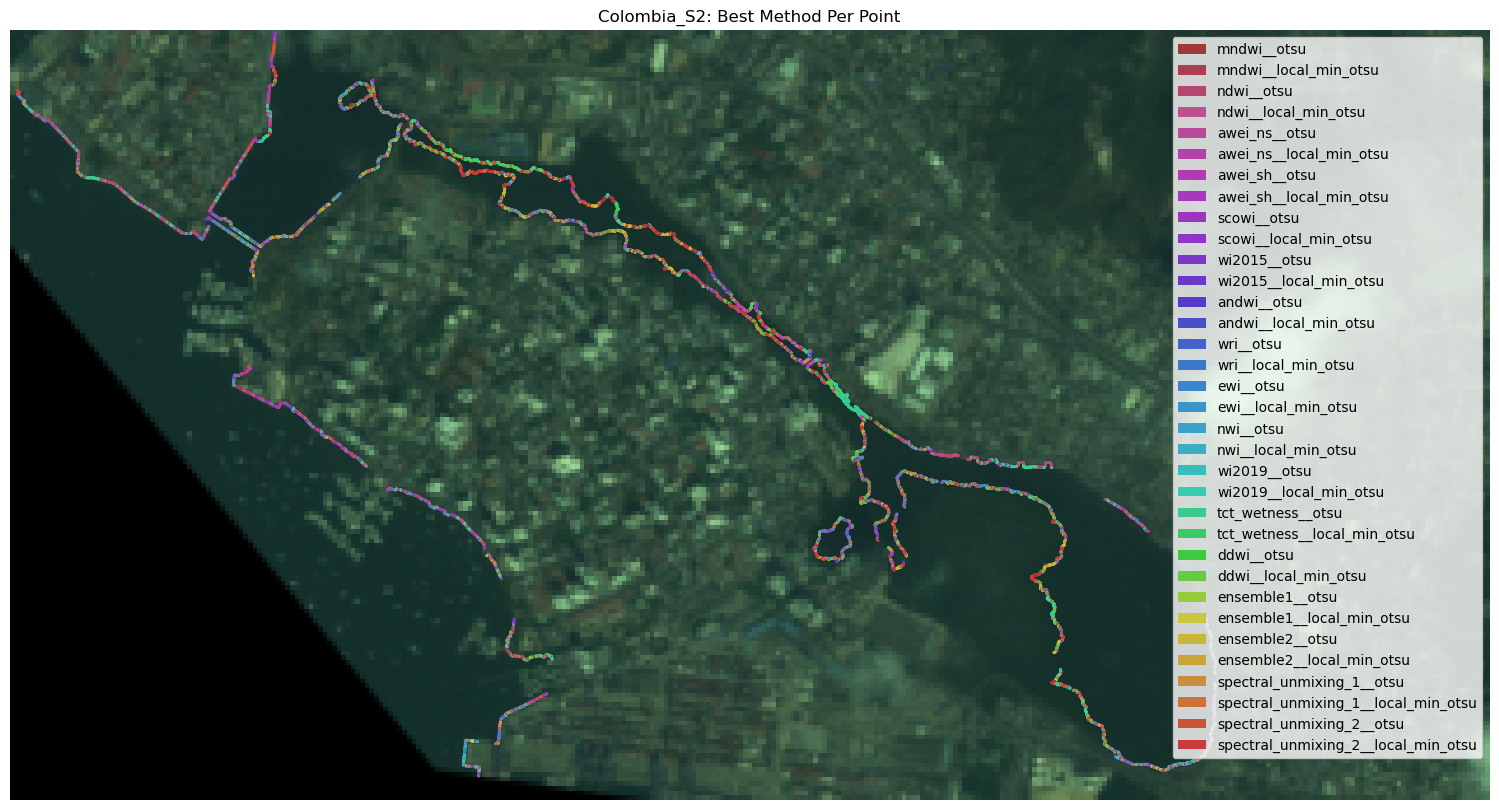

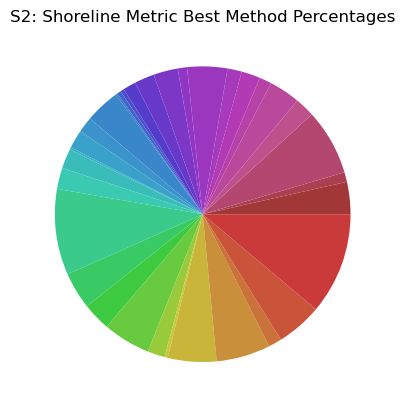

In [16]:
# fig = wvep.plot_best_score_per_point(sl_values, ref_sl_points_pxl, sim_bands[:,:,[2, 1, 0]], sitename, sim_sat)
fig = wvep.plot_best_method_per_point(best_per_point_idx, methods, ref_sl_points_pxl, sim_bands[:,:,[2, 1, 0]], sitename, sim_sat)
fig = wvep.plot_best_method_counts(best_per_point_idx, methods, sim_sat + ": Shoreline Metric Best Method Percentages", pie_instead=True)

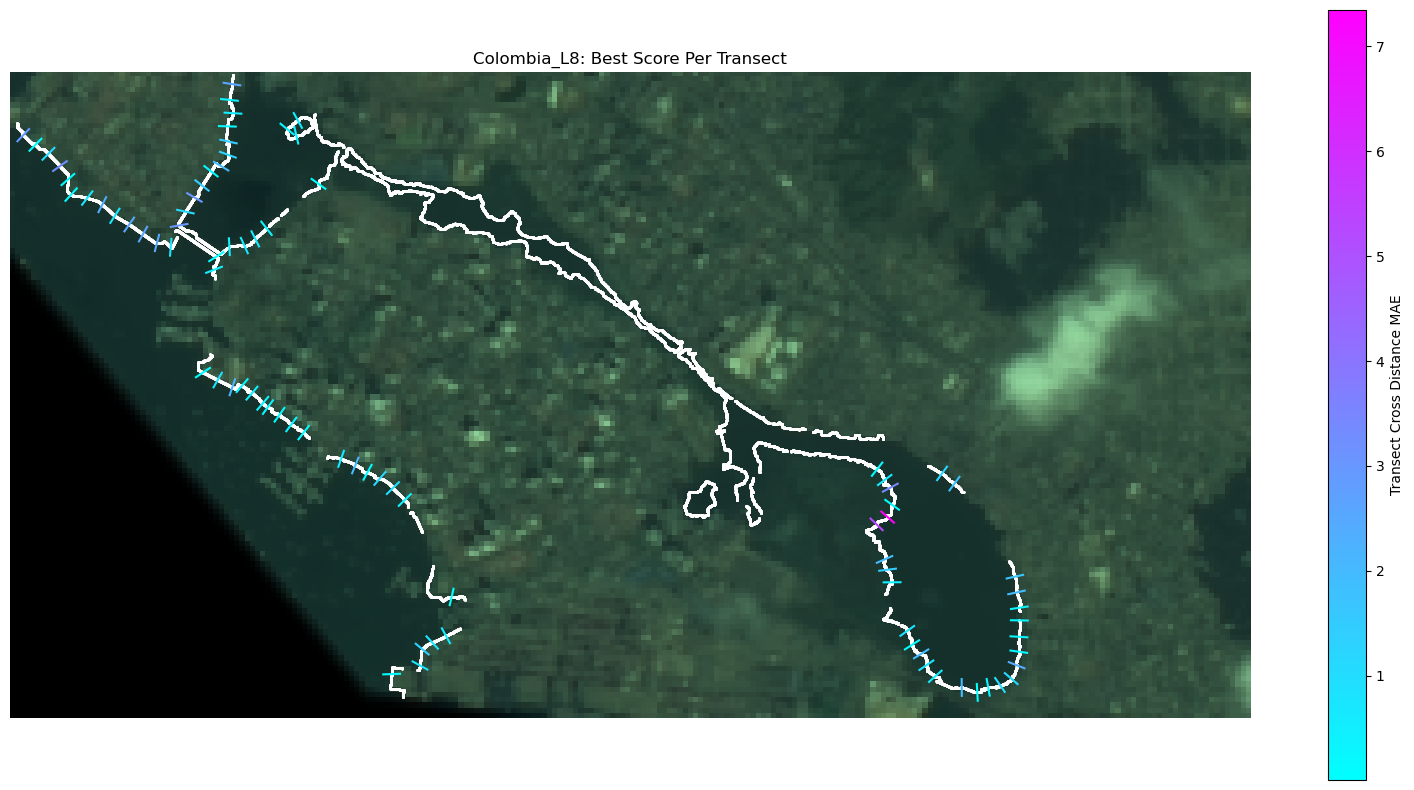

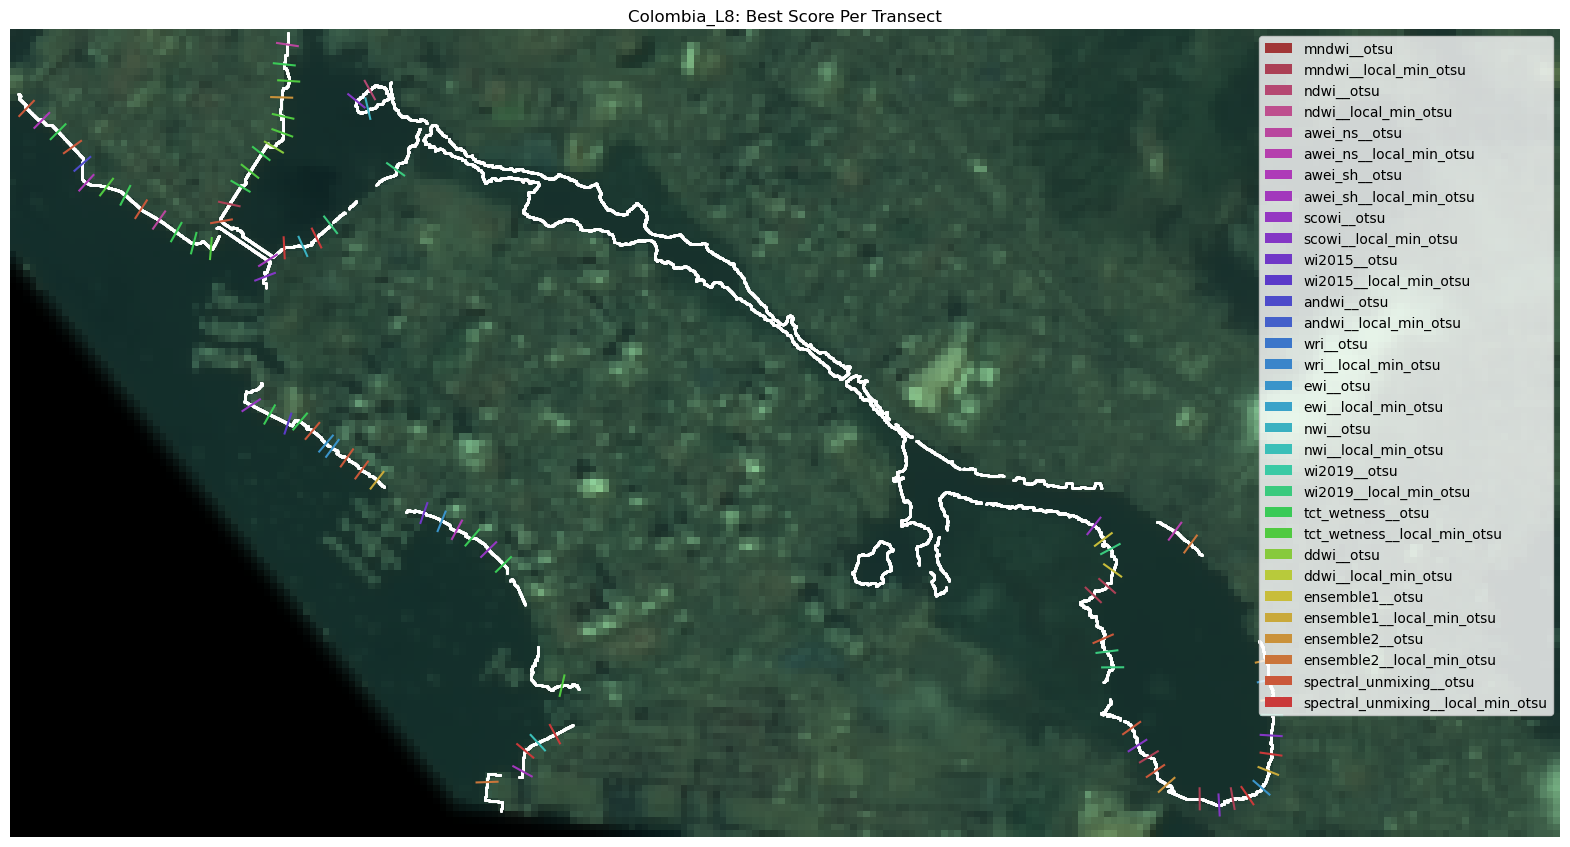

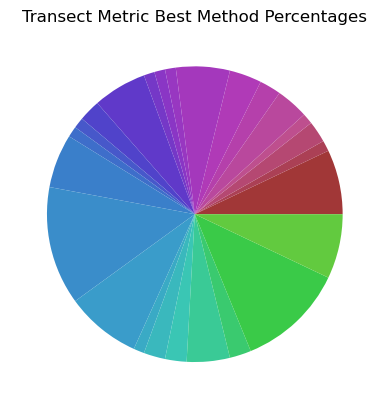

In [106]:
fig = wvep.plot_best_score_per_transect(t_values, transects_pix, ref_sl_points_pxl, sim_bands[:,:,[2, 1, 0]], sitename, sim_sat)
fig = wvep.plot_best_method_per_transect(best_per_transect_idx, methods, transects_pix, ref_sl_points_pxl, sim_bands[:,:,[2, 1, 0]], sitename, sim_sat)
fig = wvep.plot_best_method_counts(best_per_transect_idx, methods, "Transect Metric Best Method Percentages", pie_instead=True)

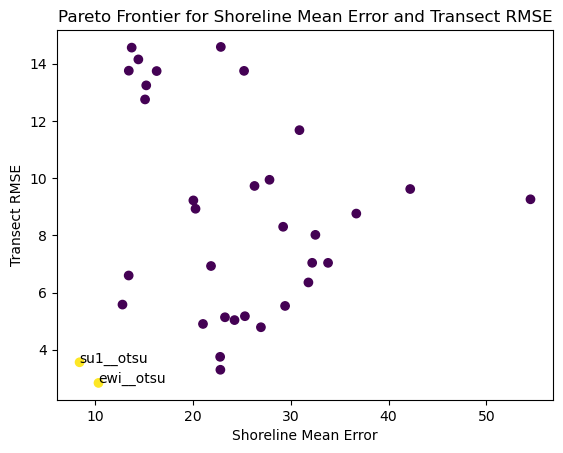

In [33]:
# sl_rmse = np.sqrt(np.nanmean(shoreline_metric[:,~outlier_idx] ** 2, axis=1))
sl_rmse = np.sqrt(np.nanmean(shoreline_metric ** 2, axis=1))
sl_mae = np.mean(shoreline_metric, axis=1)
t_rmse = np.sqrt(np.nanmean(transect_metric ** 2, axis=1))

fig = wvep.plot_pareto_front(sl_mae, t_rmse, "Shoreline Mean Error", "Transect RMSE", methods)

## Boxplots

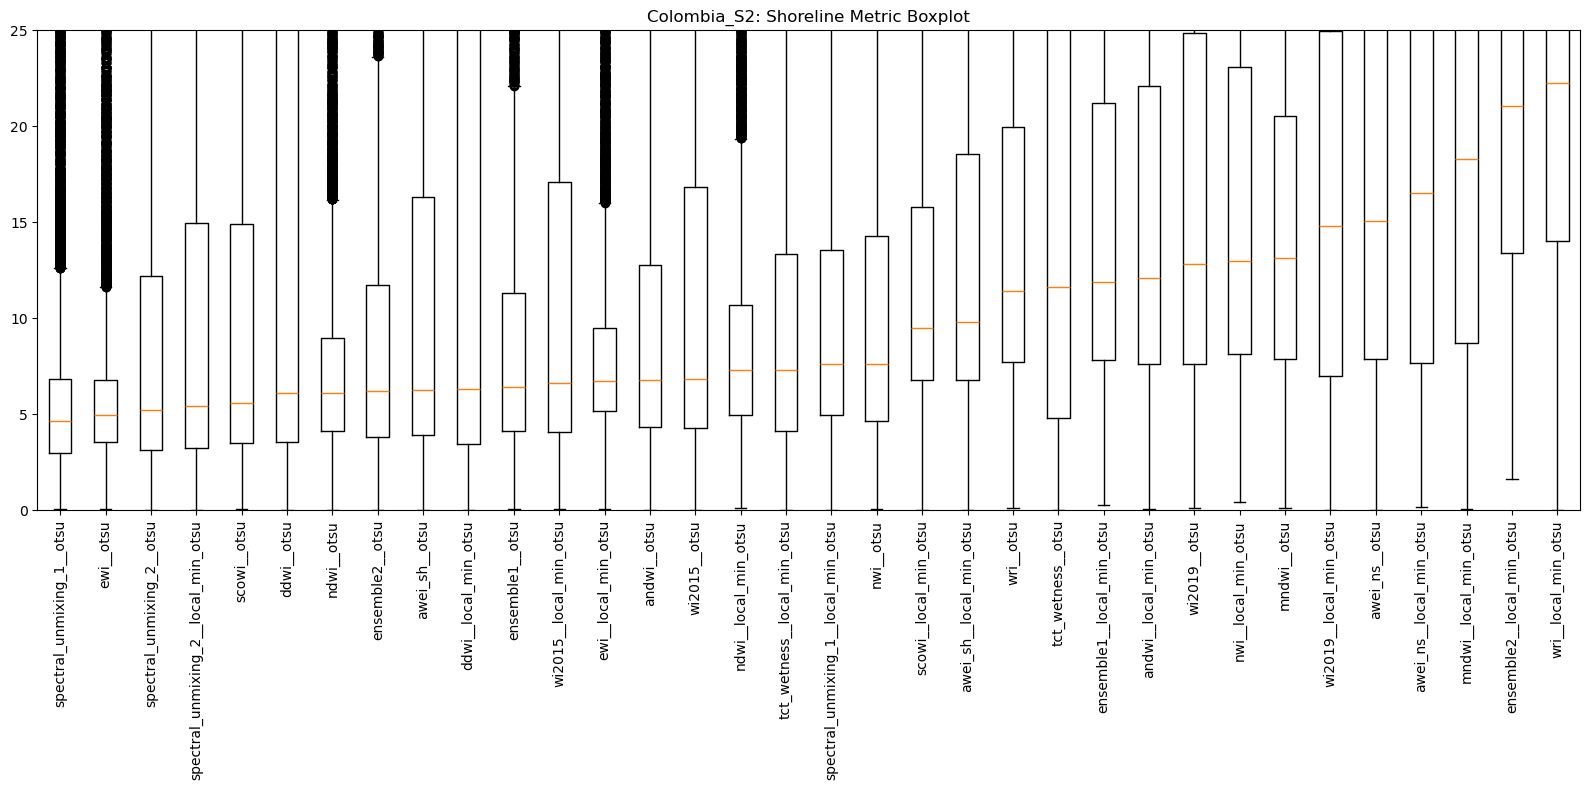

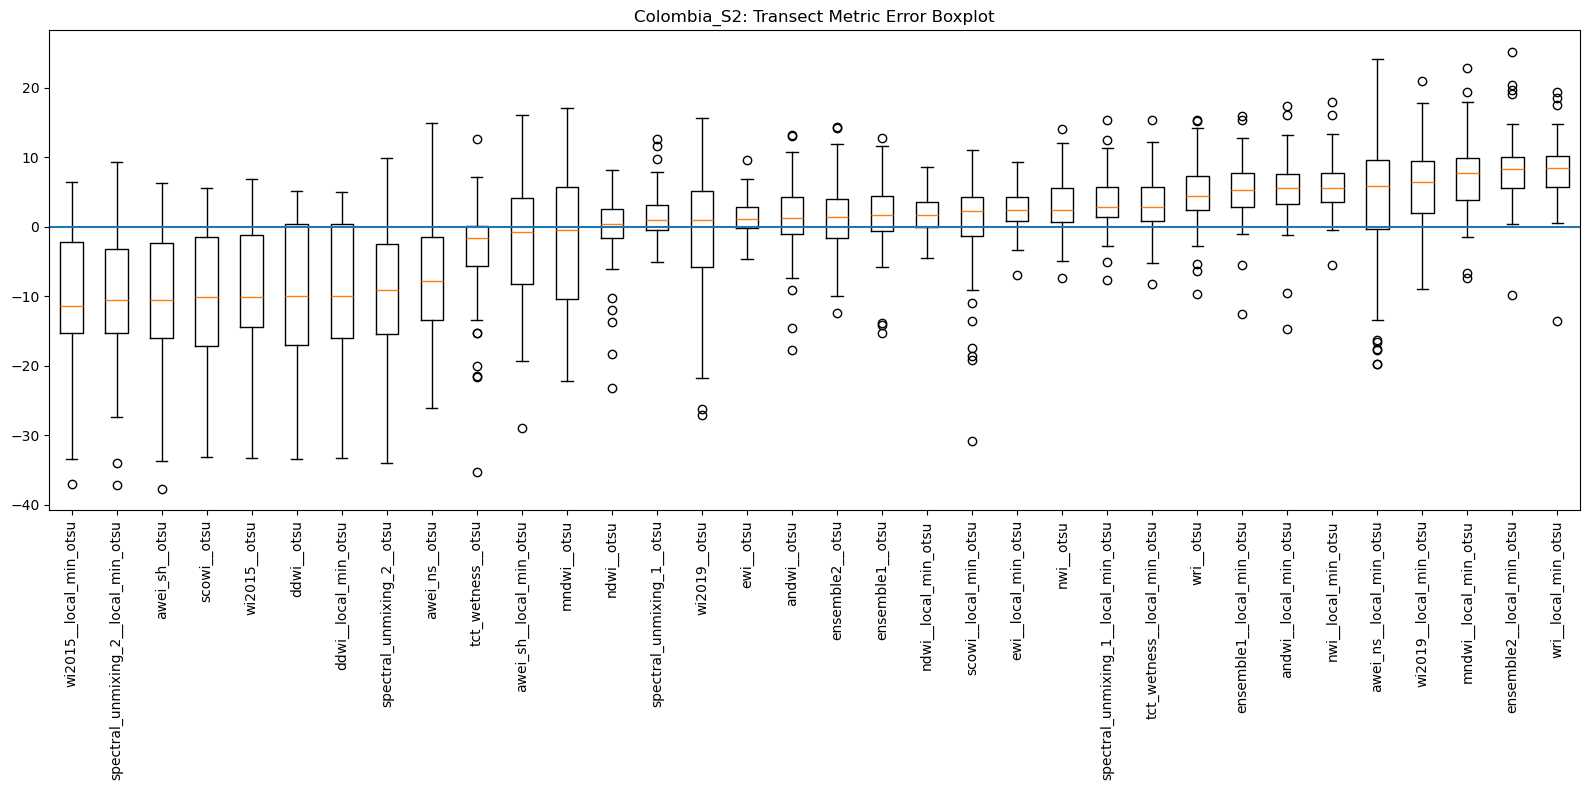

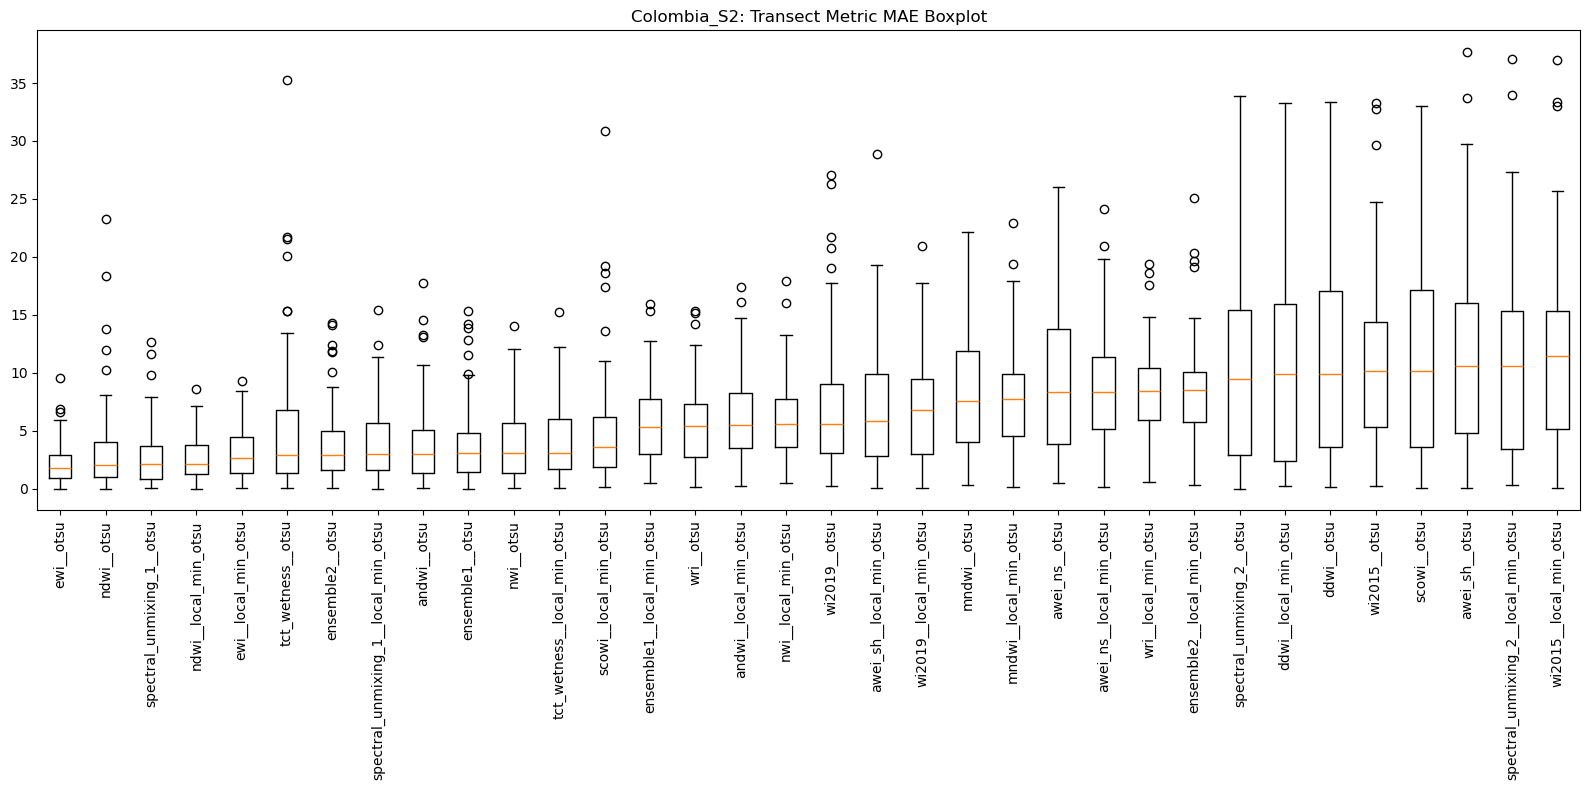

In [ ]:
title = f"{sitename}_{sim_sat}: Shoreline Metric Boxplot"
fig, ax = wvep.violin_plots(shoreline_metric, methods, title, ylim=(0, 25), box_instead=True, sort_methods=True)
title = f"{sitename}_{sim_sat}: Transect Metric Error Boxplot"
fig, ax = wvep.violin_plots(transect_metric, methods, title, box_instead=True, sort_methods=True)
ax.axhline(0)
title = f"{sitename}_{sim_sat}: Transect Metric MAE Boxplot"
fig, ax = wvep.violin_plots(np.abs(transect_metric), methods, title, box_instead=True, sort_methods=True)

## Binarize Index Comparison

Metrics mostly show improvement when binarization is applied (including for spectral unmixing method (very sad)). This is evidence against the subpixel assumption

In [155]:
shoreline_metric, transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs
)
entries, outlier_idx = wv_eval.organize_metrics(shoreline_metric, transect_metric, methods)

bin_shoreline_metric, bin_transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs, binarize=True
)
bin_entries, outlier_idx = wv_eval.organize_metrics(bin_shoreline_metric, bin_transect_metric, methods, outlier_idx)

32it [00:12,  2.51it/s]
32it [00:13,  2.32it/s]


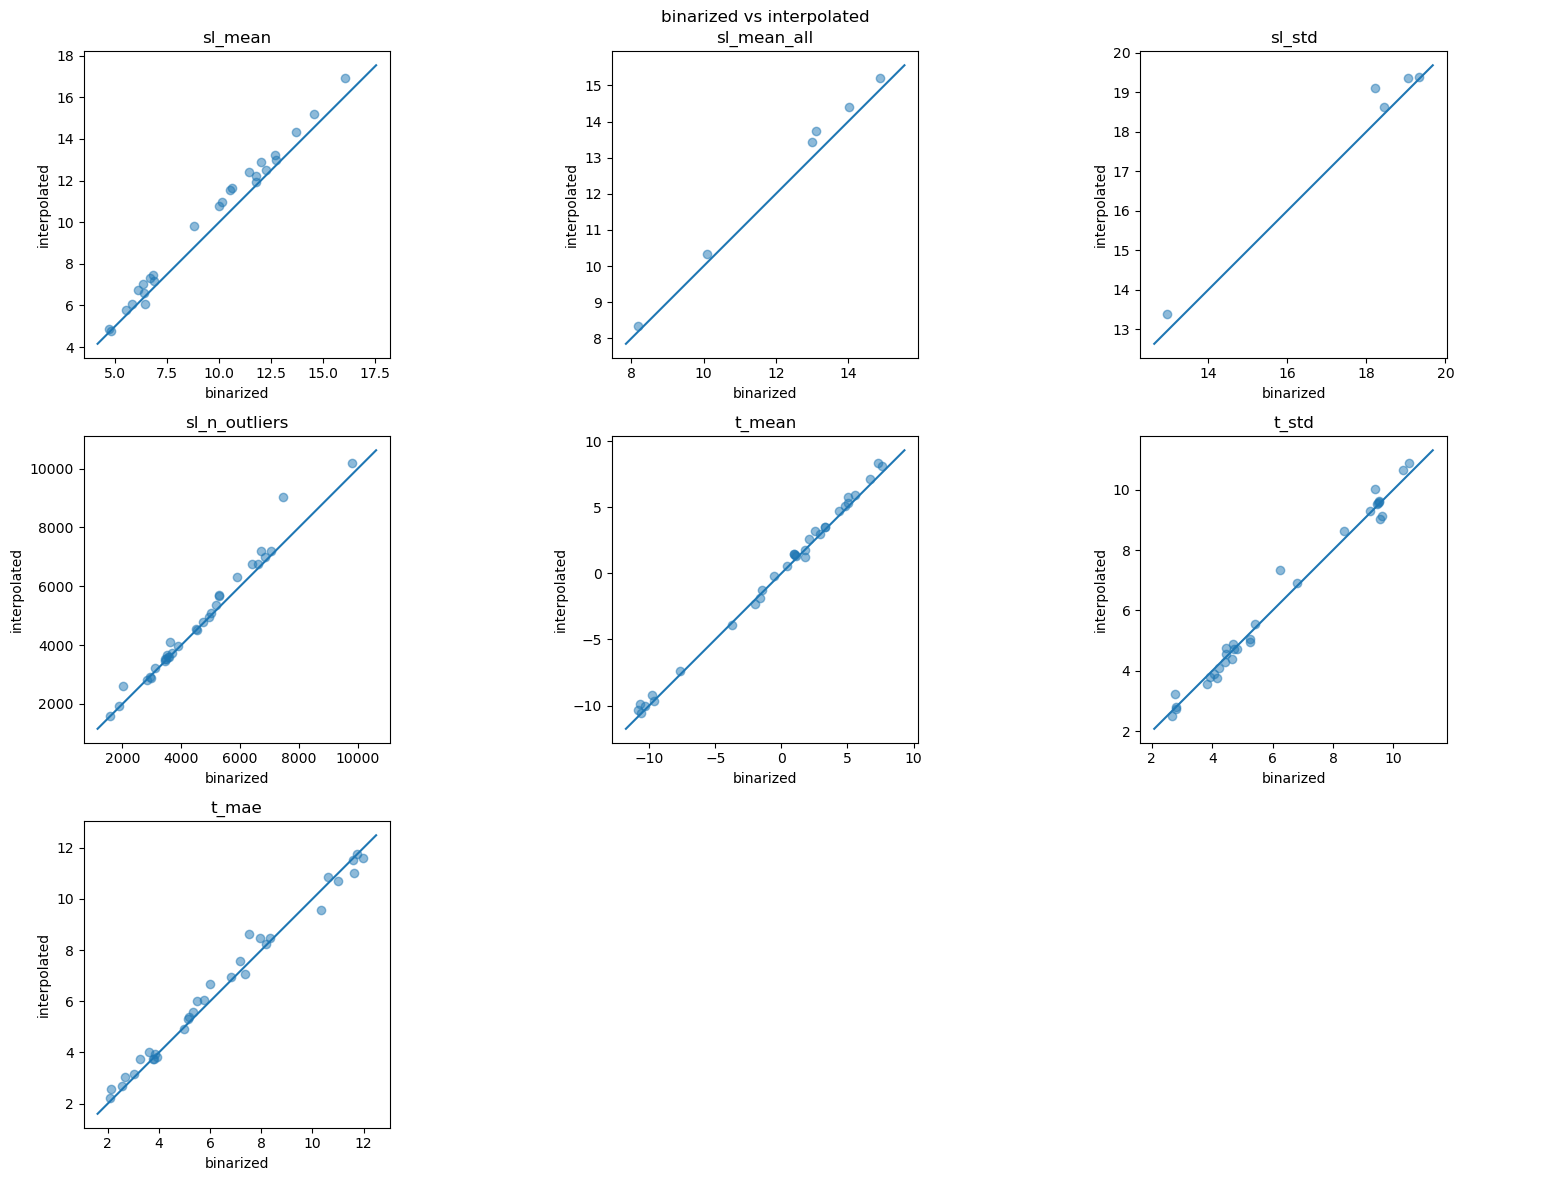

In [154]:
metrics = list(entries[0].keys())[1:]
fig = wvep.plot_comparison(bin_entries, entries, "binarized", "interpolated", metrics, sl_lim=20)

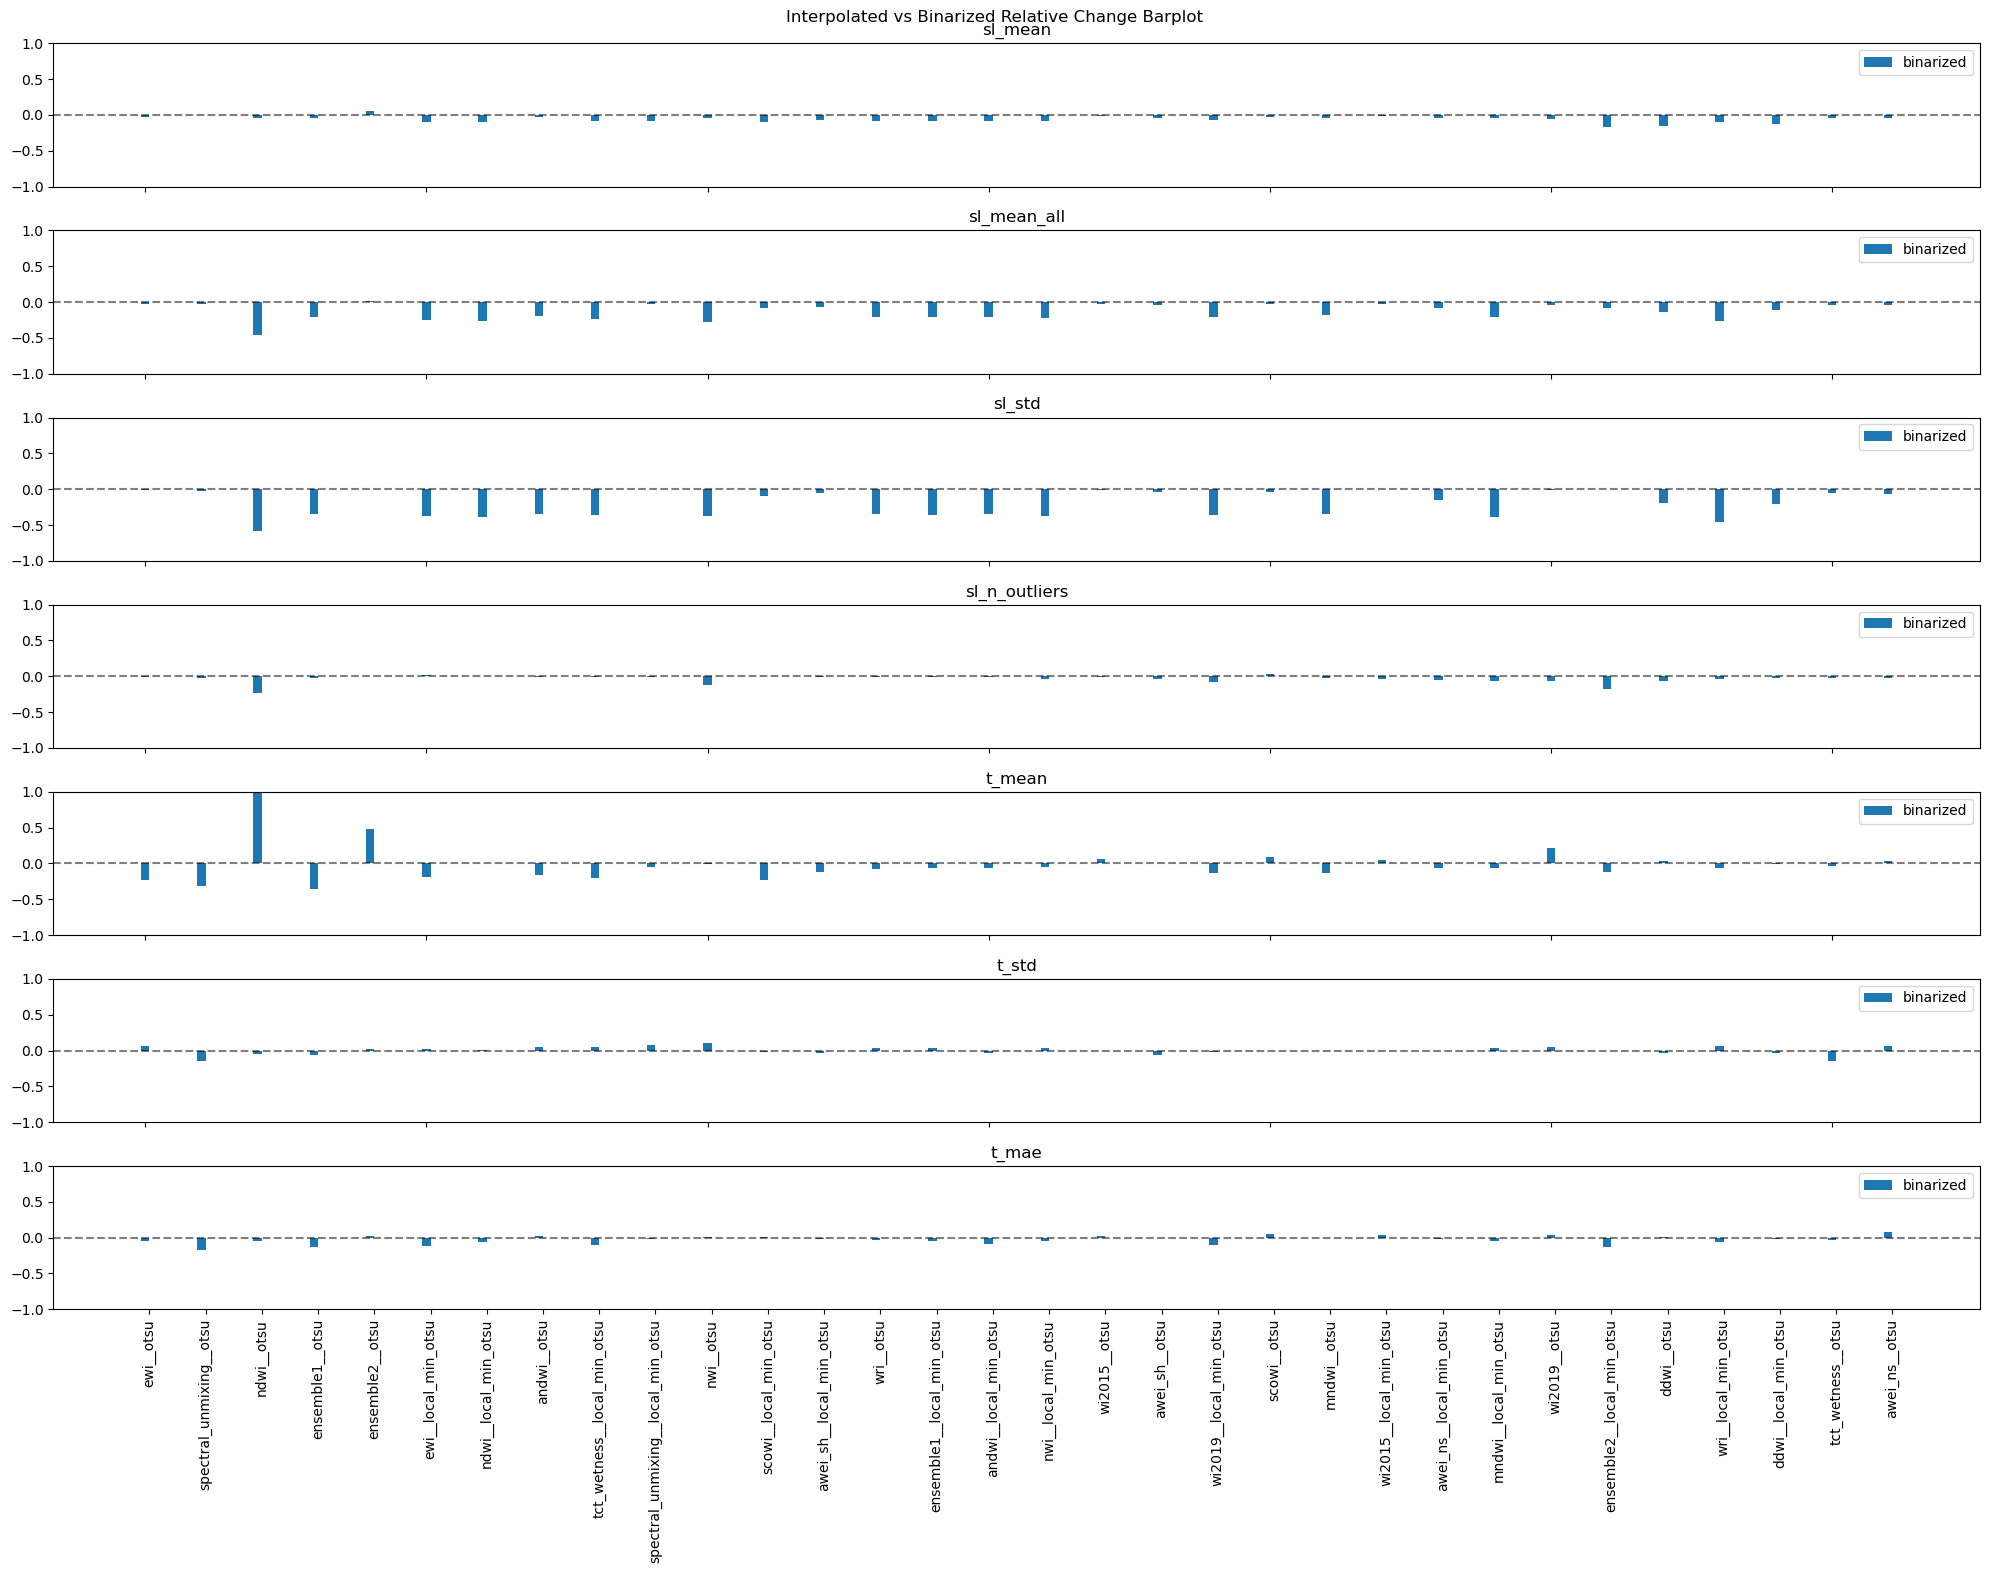

In [162]:
entries_arr = [entries, bin_entries]
titles = ["interp", "binarized"]
plot_title = "Interpolated vs Binarized Relative Change Barplot"
fig = wvep.plot_comparison_barplot(entries_arr, titles, plot_title)

In [153]:
wv_eval.print_metrics(entries, sort_variable="sl_mean")
print("\n")
wv_eval.print_metrics(bin_entries, sort_variable="sl_mean")

Sorted by sl_mean                   sl_mean      sl_mean_all  sl_std       sl_outlier     t_mean       t_std        t_mae       
spectral_unmixing__otsu:            4.783        8.351        13.374       1604           1.442        3.217        2.566       
ewi__otsu:                          4.863        10.335       18.628       1929           1.352        2.497        2.198       
ndwi__otsu:                         5.796        21.018       47.545       2610           -0.163       4.899        3.159       
ensemble1__otsu:                    6.051        22.889       46.776       3530           1.502        4.769        3.745       
ensemble2__otsu:                    6.066        22.231       45.834       3455           1.207        4.731        3.753       
andwi__otsu:                        6.590        23.266       46.358       3592           1.303        4.968        3.823       
ewi__local_min_otsu:                6.722        22.772       49.223       2901           2.576  

## Comparing Local Extraction Methods

Seems like basically noise, except for notable improvements on difficult areas (visible in improved sl_mean_all, sl_std, and n_outliers).

This is some more shaky evidence that WI are not proficient at representing sub-pixel water contents

WI2015 has some odd behaviour, maybe worth investigating, but for this location the index seems pretty garbage so why bother

Unclear if LSE1 or LSE2 is better

In [4]:
# define hand-partitioned zones
coords_pxl = ref_sl_points_pxl[::100]
zone_indicators = np.zeros((len(coords_pxl)), dtype=int)
zone_indicators[:80] = 0
zone_indicators[80:104] = 1
zone_indicators[104:119] = 2
zone_indicators[119:141] = 1
zone_indicators[141:146] = 2
zone_indicators[146:163] = 3
zone_indicators[163:189] = 4
zone_indicators[189:216] = 5
zone_indicators[216:221] = 2
zone_indicators[221:] = 6

shoreline_metric, transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs
)

lse1_shoreline_metric, lse1_transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs, lse1=True
)

lse2_shoreline_metric, lse2_transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs, lse2=True
)

lse_sanity_shoreline_metric, lse_sanity_transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs, lse2=True, zones=zone_indicators
)

entries, outlier_idx = wv_eval.organize_metrics(shoreline_metric, transect_metric, methods)
lse1_entries, _ = wv_eval.organize_metrics(lse1_shoreline_metric, lse1_transect_metric, methods, outlier_idx)
lse2_entries, _ = wv_eval.organize_metrics(lse2_shoreline_metric, lse2_transect_metric, methods, outlier_idx)
lse_sanity_entries, _ = wv_eval.organize_metrics(lse_sanity_shoreline_metric, lse_sanity_transect_metric, methods, outlier_idx)

34it [00:14,  2.41it/s]
34it [00:36,  1.08s/it]
34it [00:16,  2.12it/s]
34it [00:15,  2.25it/s]


In [9]:
sort_var = "sl_mean_all"
wv_eval.print_metrics(entries, sort_variable=sort_var)
print("\n")
wv_eval.print_metrics(lse1_entries, sort_variable=sort_var)

Sorted by sl_mean_all               sl_mean      sl_mean_all  sl_std       sl_outlier     t_mean       t_std        t_mae       
spectral_unmixing_1__otsu:          4.793        8.351        13.374       1604           1.442        3.217        2.566       
ewi__otsu:                          4.882        10.335       18.628       1929           1.352        2.497        2.198       
scowi__otsu:                        10.587       13.433       20.625       2867           -9.857       9.598        11.019      
awei_sh__otsu:                      10.329       13.729       19.092       3222           -10.557      10.034       11.760      
wi2015__local_min_otsu:             11.138       14.411       19.379       3651           -10.362      9.639        11.581      
spectral_unmixing_2__otsu:          11.820       15.201       35.253       2592           -9.154       8.950        10.161      
wi2015__otsu:                       10.085       15.216       20.574       3735           -9.187 

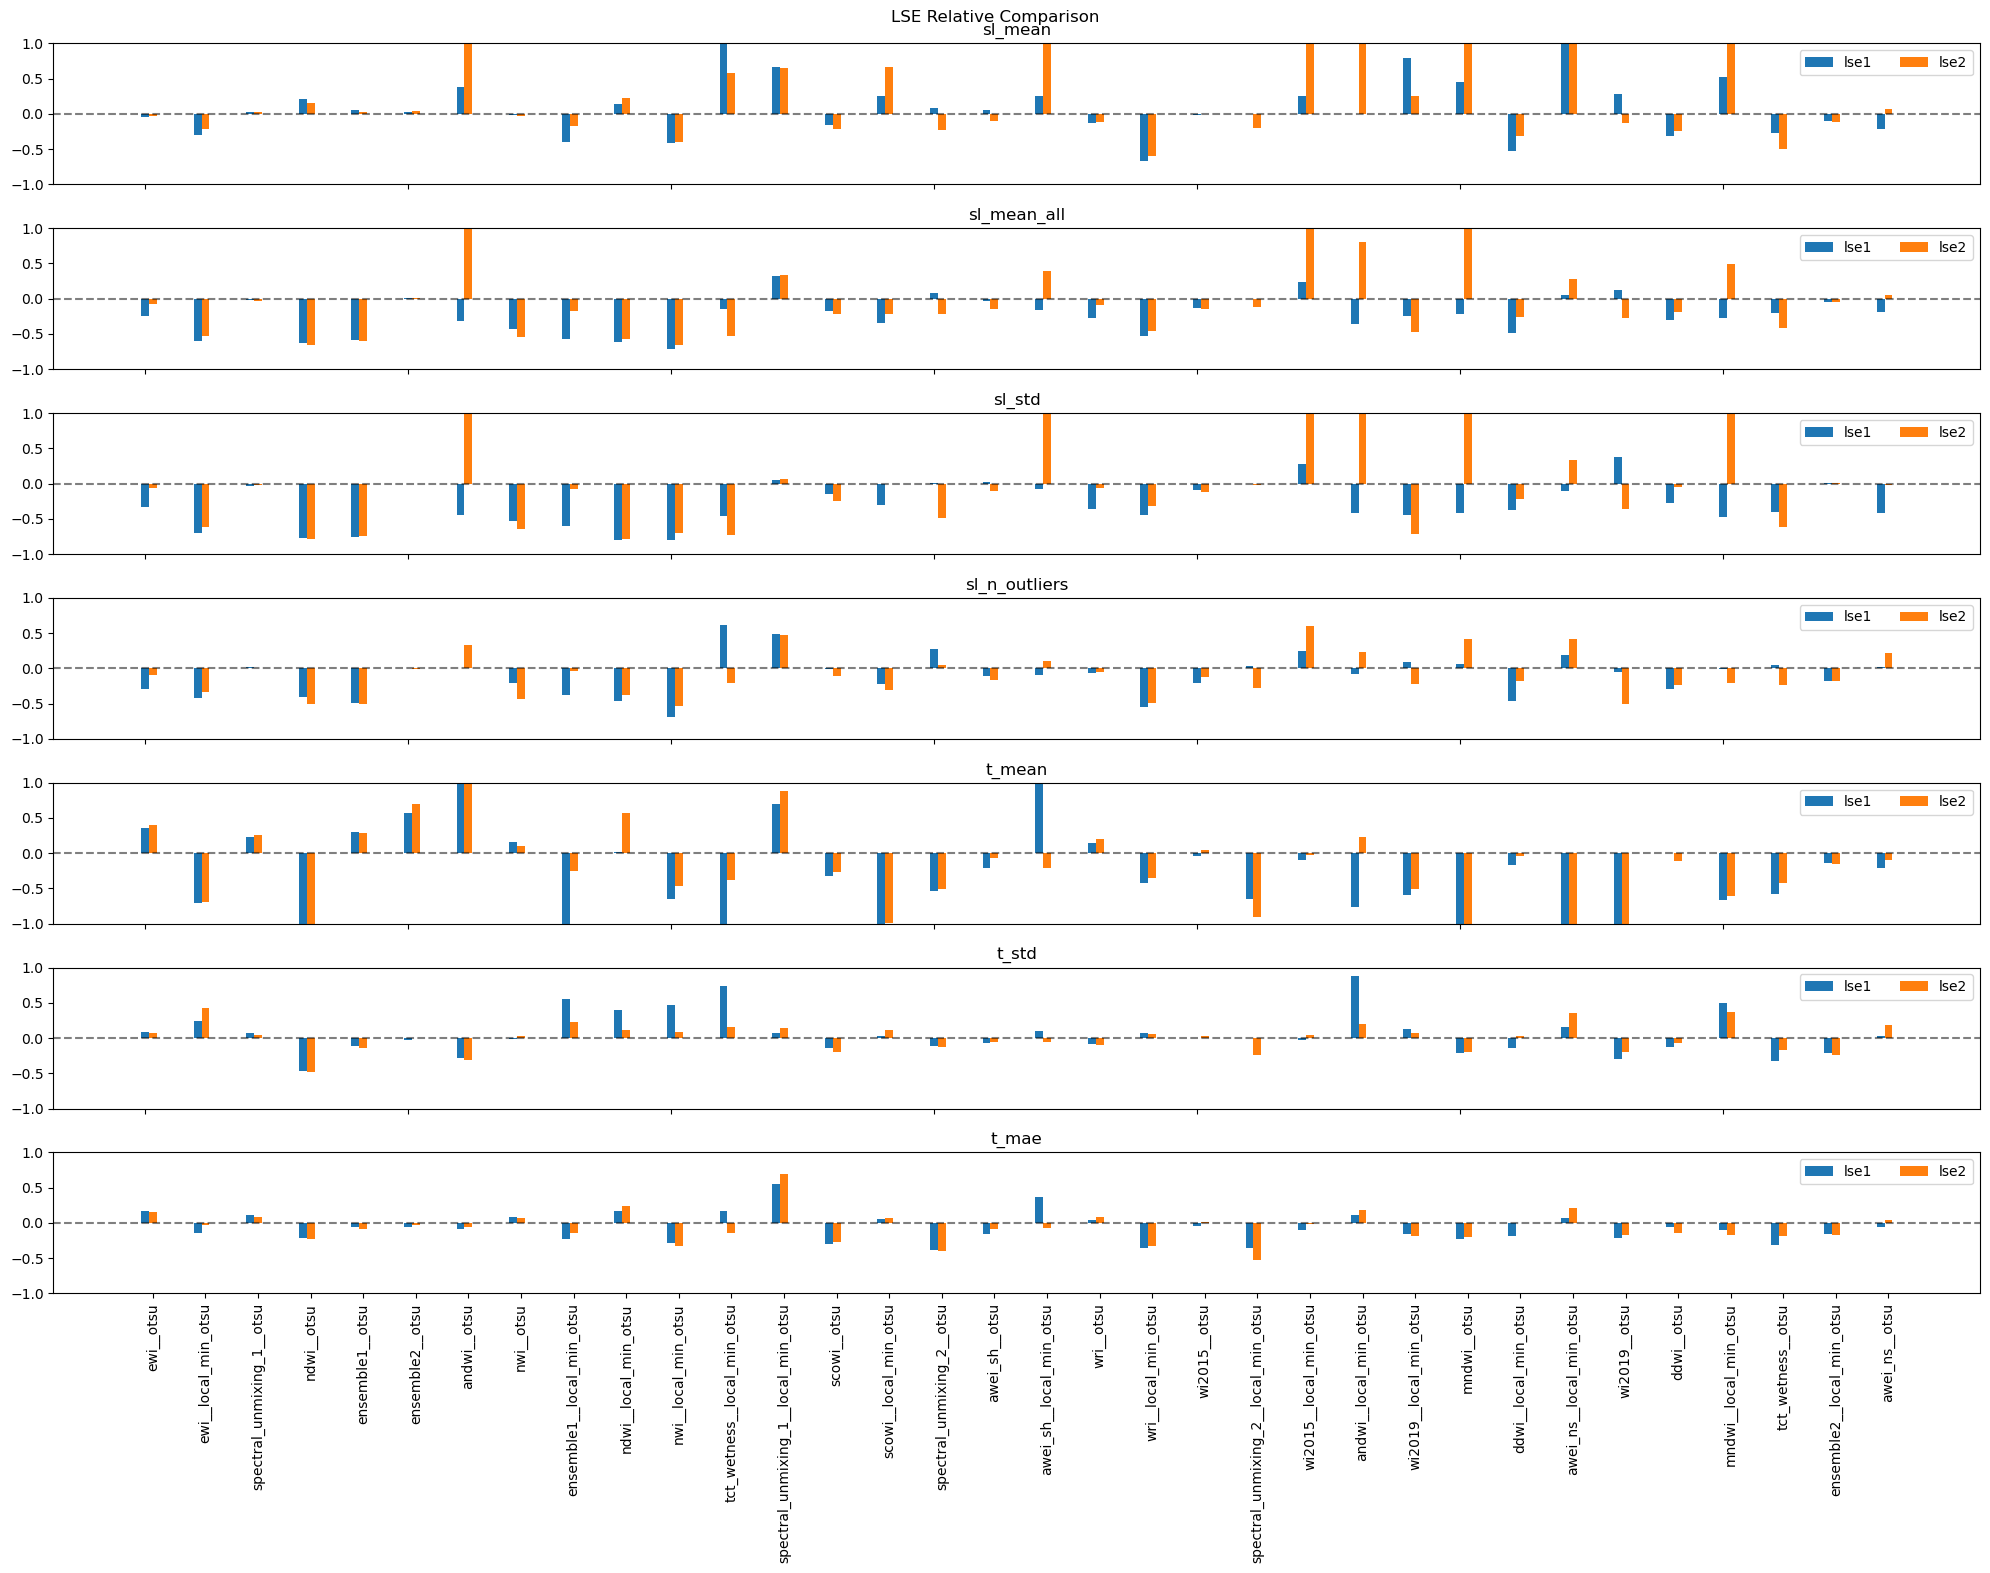

In [11]:
# entries_arr = [entries, lse1_entries, lse2_entries, lse_sanity_entries]
entries_arr = [entries, lse1_entries, lse2_entries]
# titles = ["none", "lse1", "lse2", "sanity"]
titles = ["none", "lse1", "lse2"]
plot_title = "LSE Relative Comparison"
fig = wvep.plot_comparison_barplot(entries_arr, titles, plot_title)

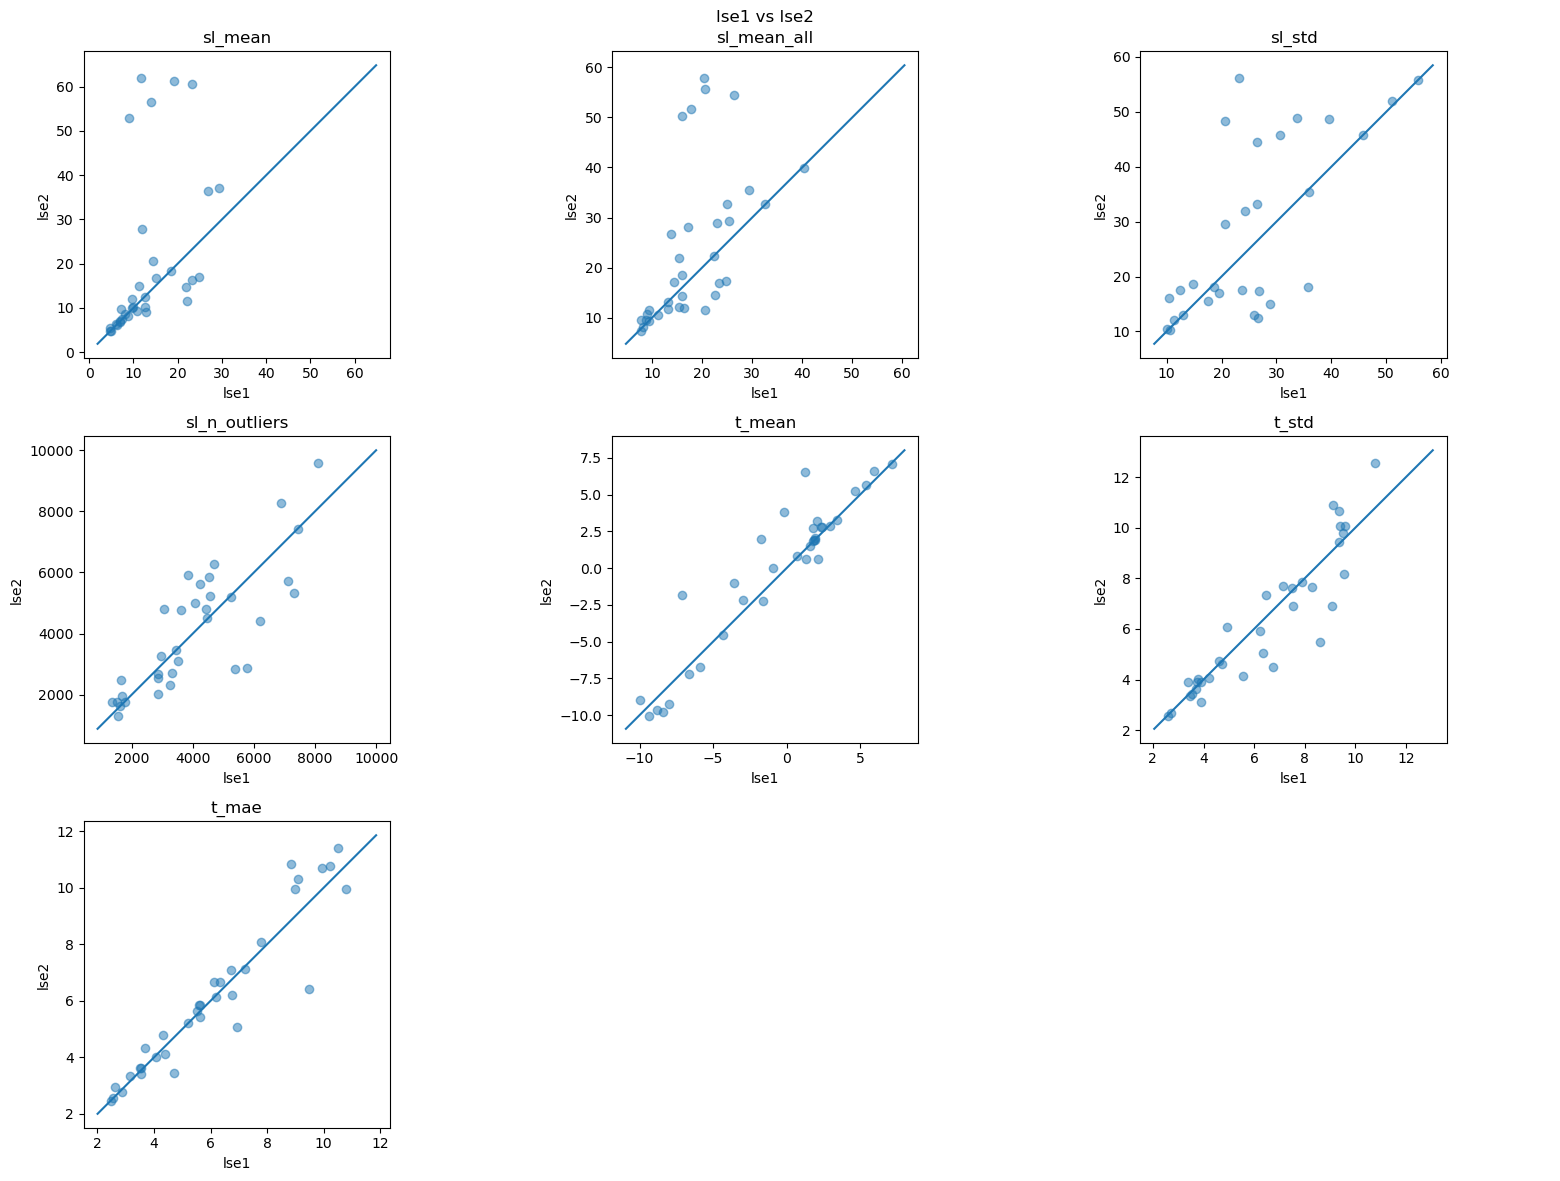

In [6]:
metrics = list(entries[0].keys())[1:]
fig = wvep.plot_comparison(lse1_entries, lse2_entries, "lse1", "lse2", metrics, sl_lim=100)

## Optimal Thresholding

Gives small improvement, therefore thresholding methods seem pretty decent. Optimal threshold changes if ignoring/including outliers. This implies that the optimal threshold changes depending on the part of the image (support for a local thresholding methodology, at least for when there's difficult areas in a subsection of an image). Should refactor so isn't running every index twice (or just remove a thresholding method). Note that ensemble2 results differ as the threshold is applied to each index before binarizing and summing together

How much of improvement is overfitting to noise vs actually improving the index selection. I.e., is the improvement evidence of WI representing sub-pixel water contents (Note that if an optimal threshold was selected for every reference shoreline point, the extracted shoreline would match it perfectly)

In addition, noisier shorelines are inadvertently encouraged due to the flaw of the shoreline metric (t_mae gets worse)

(why are some sl_mean worse? is this a threshold resolution issue?)

In [36]:
# run with regular threshold_functions to get consistent outlier_idx
shoreline_metric, transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs
)
entries, outlier_idx = wv_eval.organize_metrics(shoreline_metric, transect_metric, methods)

# run experiment
threshold_functions_temp = [otsu]
opt_shoreline_metric, opt_transect_metric, methods, opt_info = wv_eval.evaluate_methods(
    index_functions, threshold_functions_temp, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs, optimal_thresholds=True
)
shoreline_metric, transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions_temp, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs
)

# use outlier idx from run with all threshold functions for uniformity
entries, _ = wv_eval.organize_metrics(shoreline_metric, transect_metric, methods, outlier_idx)
opt_entries, _ = wv_eval.organize_metrics(opt_shoreline_metric, opt_transect_metric, methods, outlier_idx)

30it [00:11,  2.55it/s]
15it [16:28, 65.87s/it]
15it [00:07,  1.95it/s]


In [37]:
wv_eval.print_metrics(opt_entries, "sl_mean")
print("\n")
wv_eval.print_metrics(entries, "sl_mean")

                                    sl_mean      sl_mean_all  sl_std       sl_outlier     t_mean       t_std        t_mae       
ensemble1__otsu:                    5.423        6.232        7.161        706            -2.809       6.700        4.866       
andwi__otsu:                        5.773        6.562        8.151        796            -2.945       6.634        4.860       
nwi__otsu:                          5.969        6.590        8.273        885            -2.773       5.844        4.612       
ensemble2__otsu:                    6.346        6.385        6.772        572            -3.212       6.047        4.758       
ewi__otsu:                          6.368        6.985        8.612        909            -3.622       5.362        4.802       
awei_ns__otsu:                      7.024        7.486        6.566        667            -2.038       6.685        5.238       
awei_sh__otsu:                      7.198        9.977        11.714       1884           -3.574 

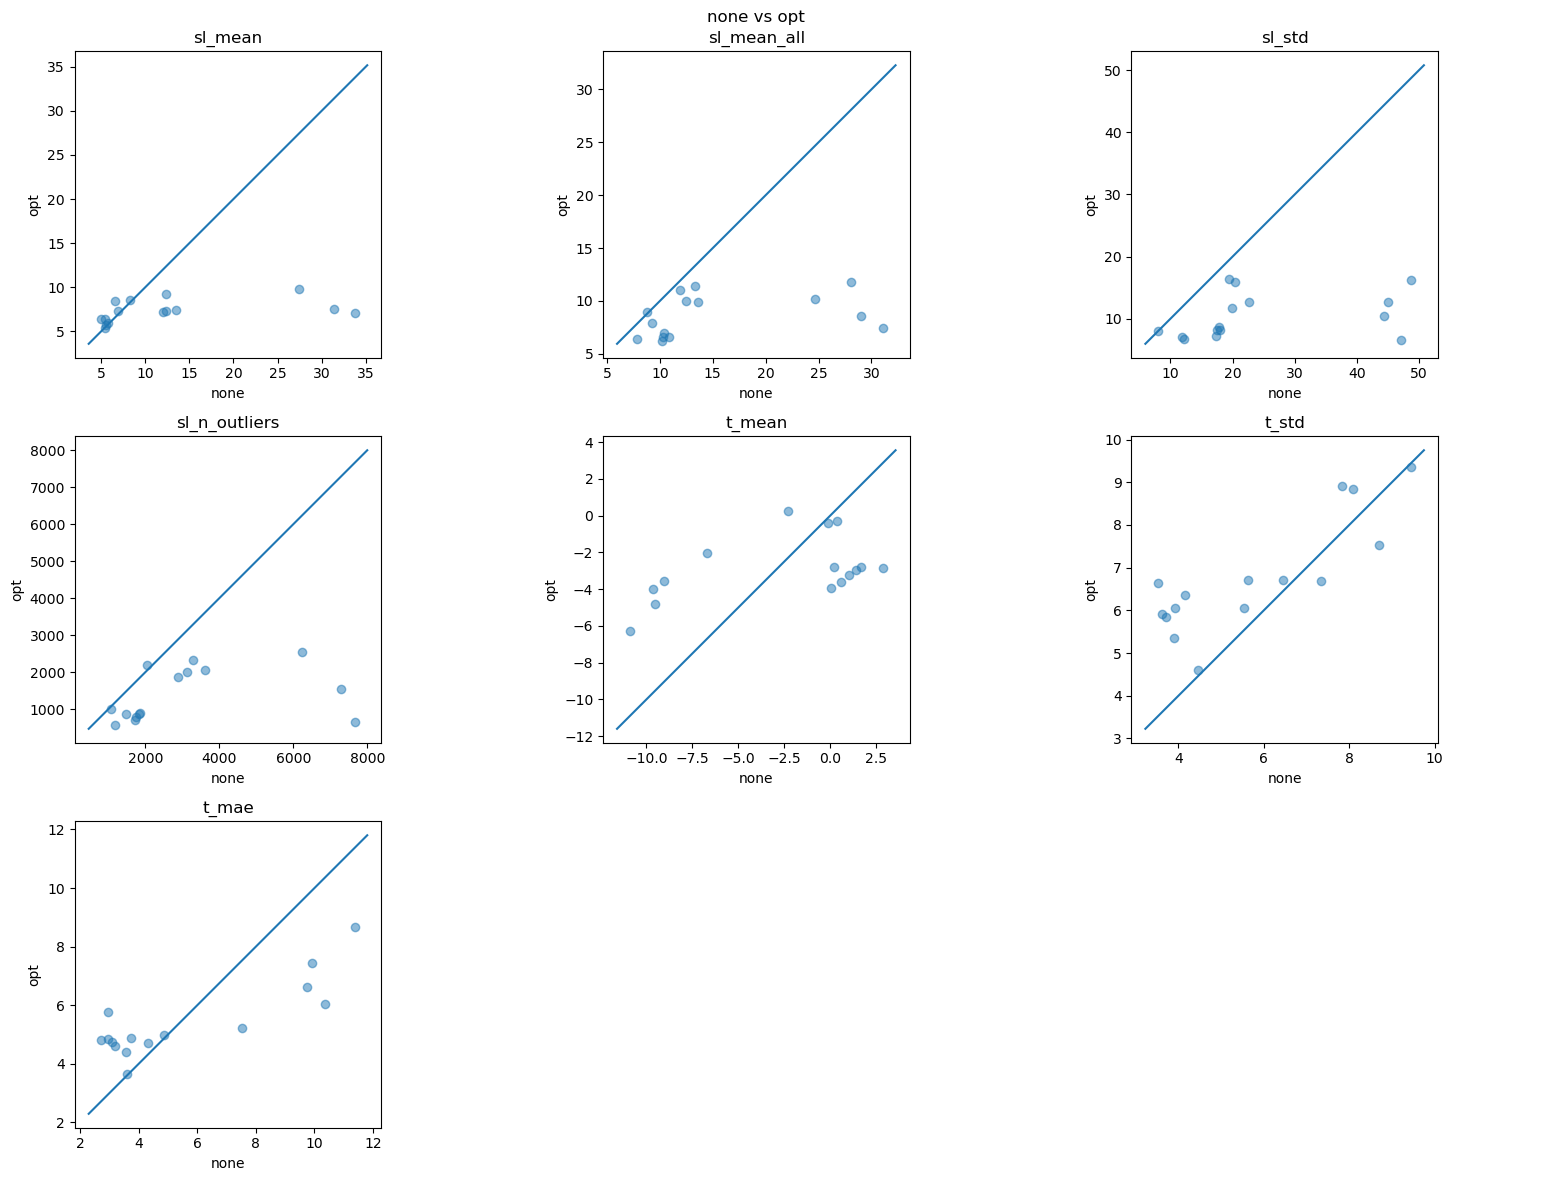

In [39]:
metrics = list(entries[0].keys())[1:]
fig = wvep.plot_comparison(entries, opt_entries, "none", "opt", metrics, sl_lim=100)

### Optimizing entire shoreline, or omitting outlier

In [ ]:
im_ind = andwi(sim_bands.reshape(-1, sim_bands.shape[-1]))

In [ ]:
ignore_outliers_contours, ignore_outliers_threshold = wv_eval.get_optimal_threshold(im_ind.reshape(sim_bands.shape[:-1]), ref_sl_points, sds_data, outlier_idx=outlier_idx)
ignore_outliers_dists = m.get_nearest_distance(ref_sl_points, ignore_outliers_contours)
print(np.mean(ignore_outliers_dists))
print(np.mean(ignore_outliers_dists[~outlier_idx]))

9.688412532249526
5.045890616986989


In [35]:
inc_outliers_contours, inc_outliers_threshold = wv_eval.get_optimal_threshold(im_ind.reshape(sim_bands.shape[:-1]), ref_sl_points, sds_data)
inc_outliers_dists = m.get_nearest_distance(ref_sl_points, inc_outliers_contours)
print(np.mean(inc_outliers_dists))
print(np.mean(inc_outliers_dists[~outlier_idx]))

6.561689806491867
5.773254337348431


## Custom Spectral Unmixing

otsu_thresh = np.float32(0.31307507)
sl_mean: 6.306952779189938, 7.833150682771651
t_mae: 5.618122718806557


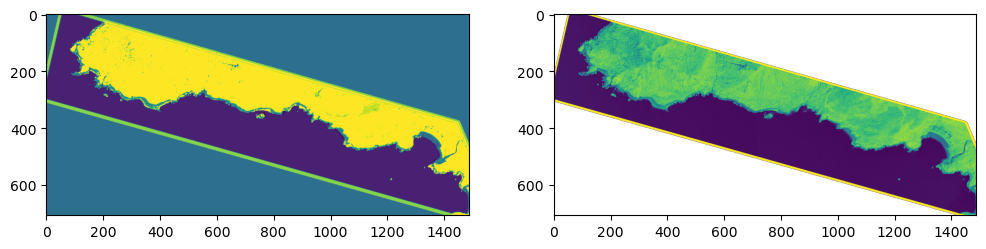

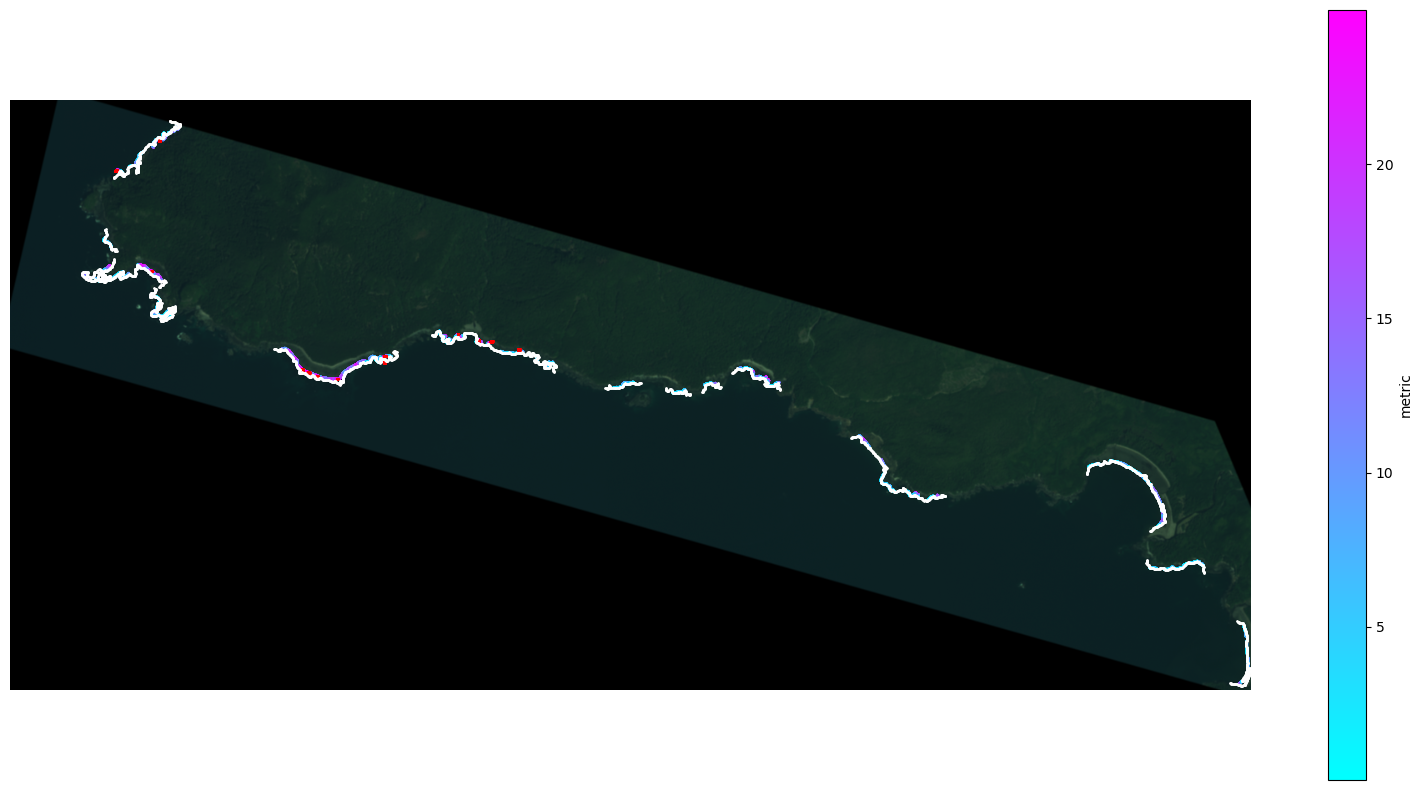

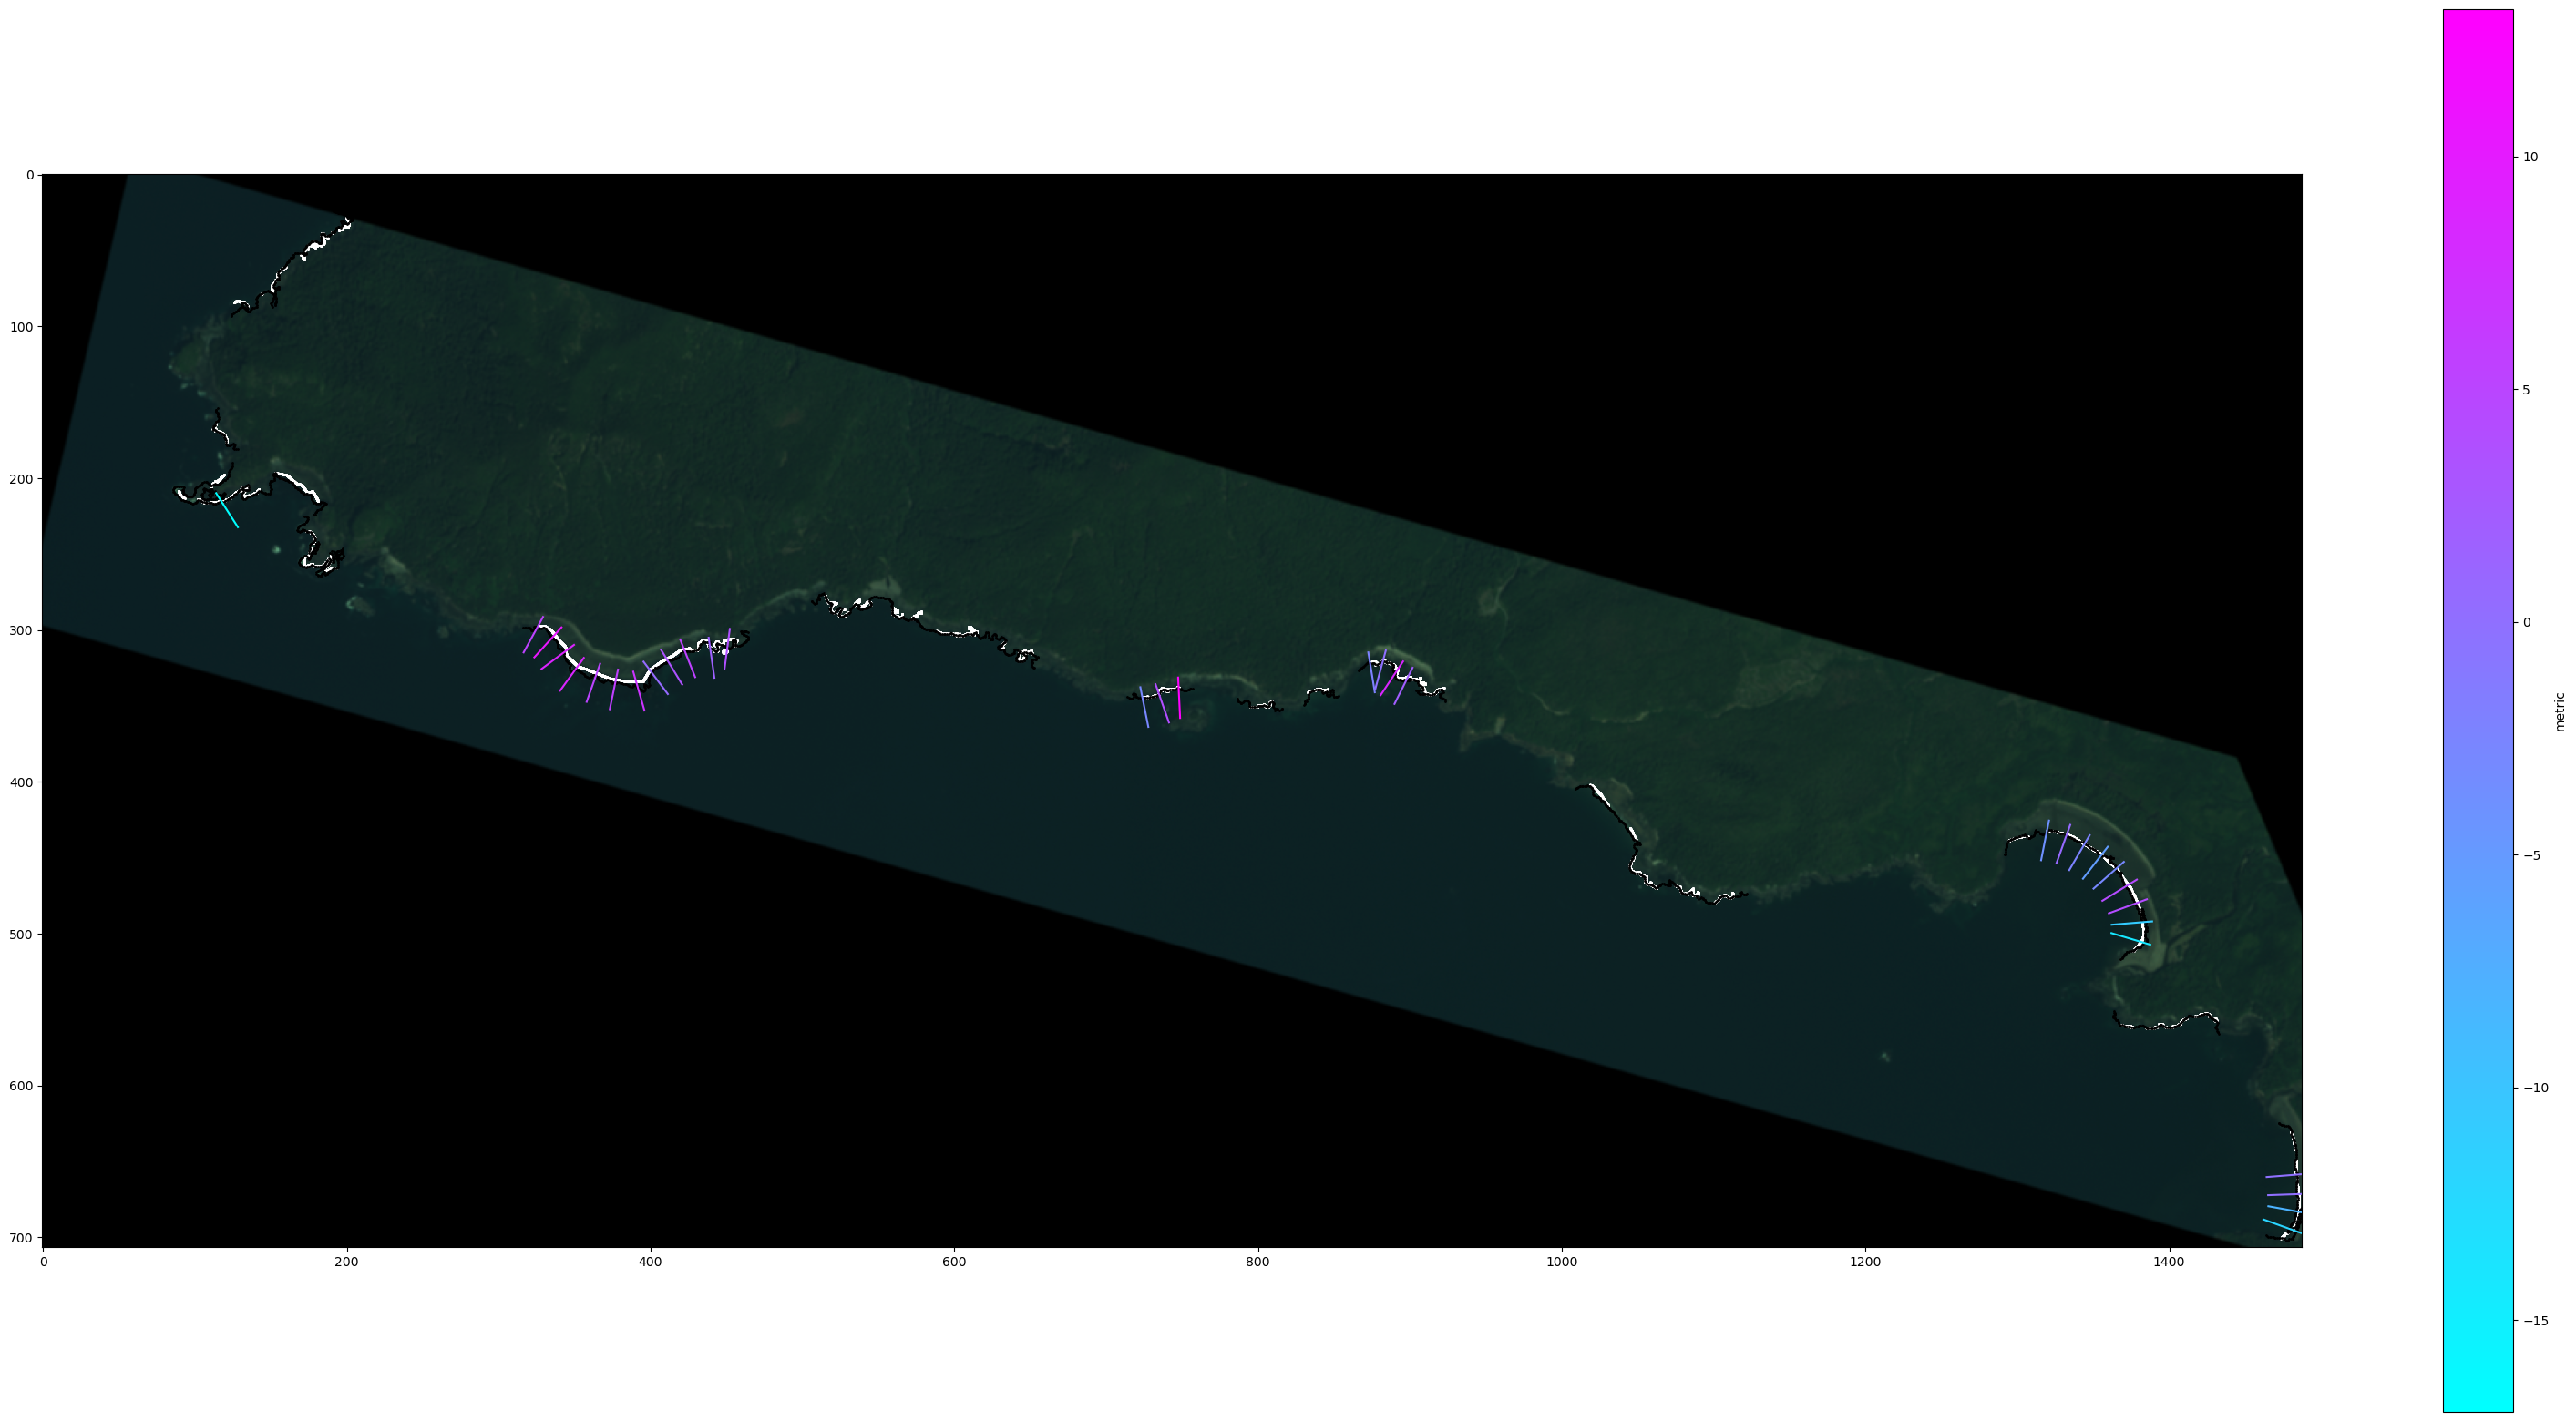

In [82]:
im_ind = ens2(sim_bands, ensemble_idx_funcs, otsu, cloud_mask, sds_data["sl_buffer"])
# im_ind = ndwi(sim_bands.reshape(-1, sim_bands.shape[-1])).reshape(sim_bands.shape[:-1])
percentages = su.spectral_unmixing_1(sim_bands, im_ind, sds_data)

fig, axs = plt.subplots(1, 2, figsize=(12, 8))
axs[0].imshow(im_ind)
axs[1].imshow(percentages.reshape(sim_bands.shape[:-1]))

otsu_thresh = otsu(percentages, cloud_mask, sds_data["sl_buffer"])
contours = wv_eval.get_contours(percentages.reshape(sim_bands.shape[:-1]), otsu_thresh, sds_data)
sl_dists = m.get_nearest_distance(ref_sl_points, contours)
t_dists, _ = m.get_median_distances(transects, ref_sl_points, contours, collider_settings)

print(f"{otsu_thresh = }")
print(f"sl_mean: {np.mean(sl_dists[~outlier_idx])}, {np.mean(sl_dists)}")
print(f"t_mae: {np.nanmean(np.abs(t_dists))}")
contour_pxl = modified_coastsat.convert_world2pix(contours, georef)
fig = wvep.plot_shoreline_metric(sl_dists, (0, 25), ref_sl_points_pxl, sim_bands[:,:,[2, 1, 0]], contours_pxl=contour_pxl)
fig = wvep.plot_transect_metric(t_dists, (-25, 25), transects_pix, ref_sl_points_pxl, sim_bands[:,:,[2, 1, 0]], contours_pxl=contour_pxl)

ValueError: supplied range of [0.6003889441490173, inf] is not finite

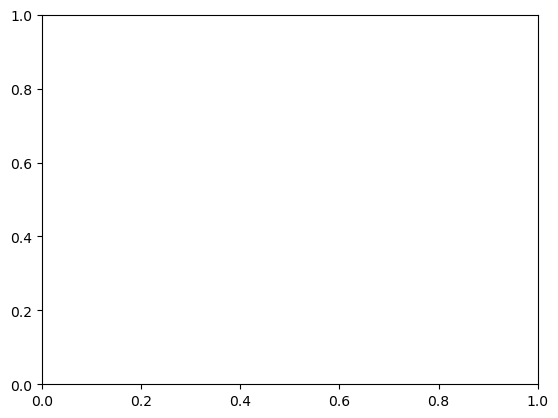

In [46]:
im_ind = ens2(sim_bands, ensemble_idx_funcs, otsu, cloud_mask, sds_data["sl_buffer"])
percentages = su.spectral_unmixing_2(sim_bands, im_ind, sds_data)
percentages[percentages < 0.6] = np.nan
otsu_thresh = otsu(percentages, cloud_mask, sds_data["sl_buffer"])

# plt.imshow(percentages.reshape(sim_bands.shape[:-1]))
plt.hist(percentages[sds_data["sl_buffer"]].ravel(), bins=256)
plt.axvline(otsu_thresh, c="black")

# contours = wv_eval.get_contours(percentages.reshape(sim_bands.shape[:-1]), 0.975, sds_data)
contours = wv_eval.get_contours(percentages.reshape(sim_bands.shape[:-1]), otsu_thresh, sds_data)
sl_dists = m.get_nearest_distance(ref_sl_points, contours)
t_dists, _ = m.get_median_distances(transects, ref_sl_points, contours, collider_settings)

print(f"sl_mean: {np.mean(sl_dists[~outlier_idx])}, {np.mean(sl_dists)}")
print(f"t_mae: {np.nanmean(np.abs(t_dists))}")
contour_pxl = SDS_tools.convert_world2pix(contours, georef)
fig = wvep.plot_shoreline_metric(sl_dists, (0, 25), ref_sl_points_pxl, sim_bands[:,:,[2, 1, 0]], contours_pxl=contour_pxl)
fig = wvep.plot_transect_metric(t_dists, (-25, 25), transects_pix, ref_sl_points_pxl, sim_bands[:,:,[2, 1, 0]], contours_pxl=contour_pxl)

## Combinations of Note

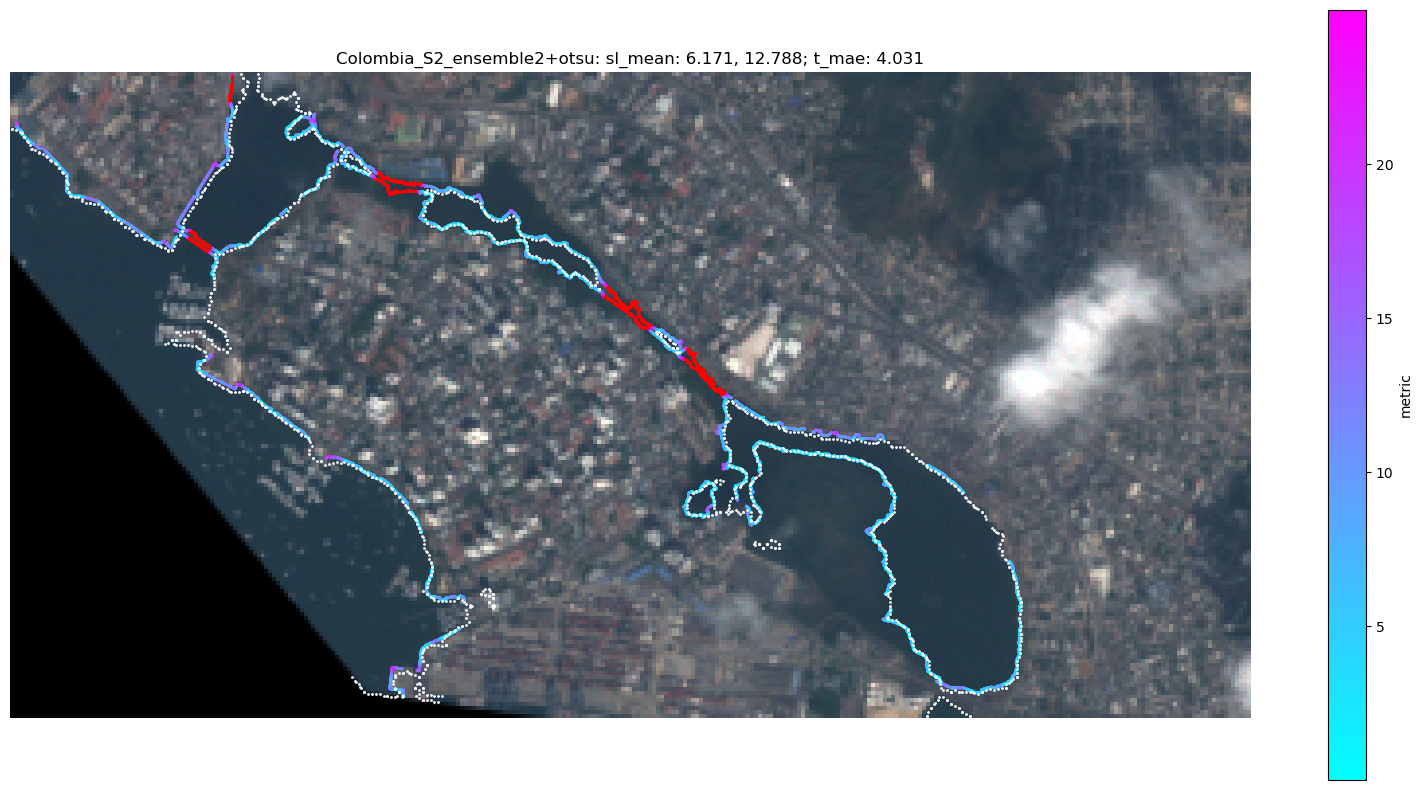

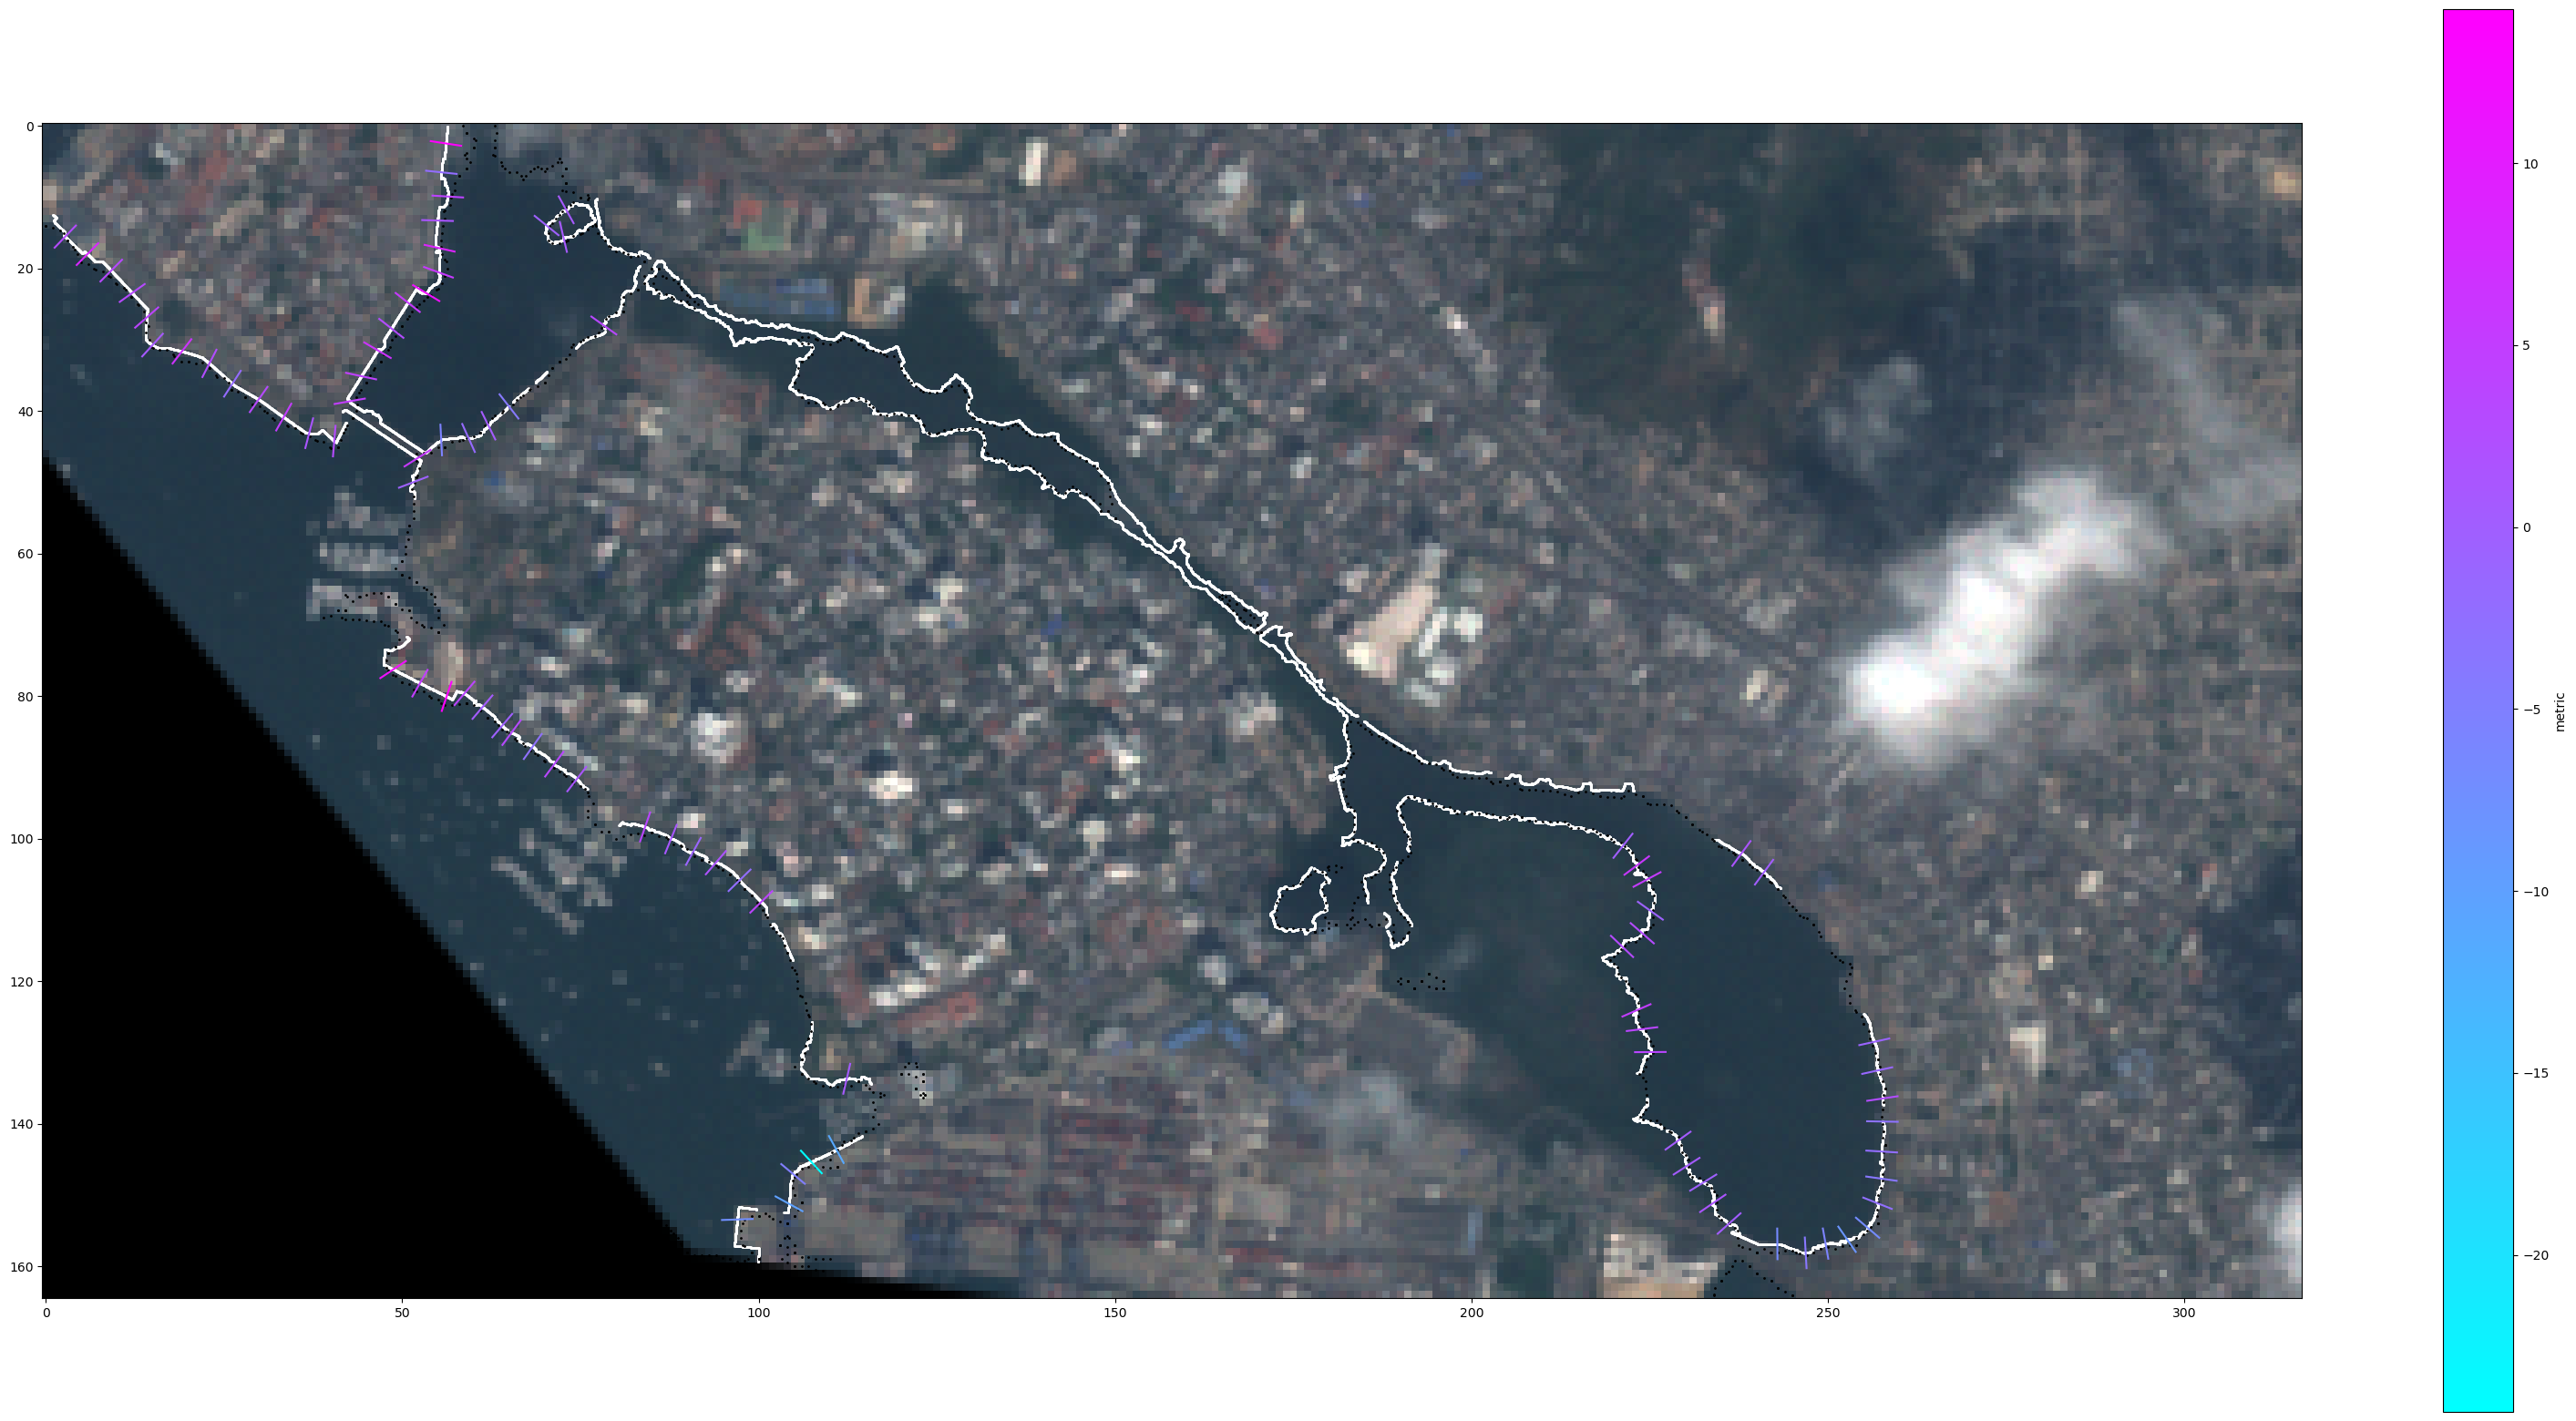

In [31]:
# Ensemble2 + Otsu
index = ensemble2(sim_bands, ensemble_idx_funcs, otsu, cloud_mask, sds_data["sl_buffer"])
threshold = otsu(index, cloud_mask, sds_data["sl_buffer"])
method = "ensemble2+otsu"
sl_fig, t_fig = wvep.plot_method(index, threshold, method, sim_bands, sds_data, ref_sl_points, ref_sl_points_pxl, transects, transects_pix, collider_settings, outlier_idx, georef, sitename, sim_sat)

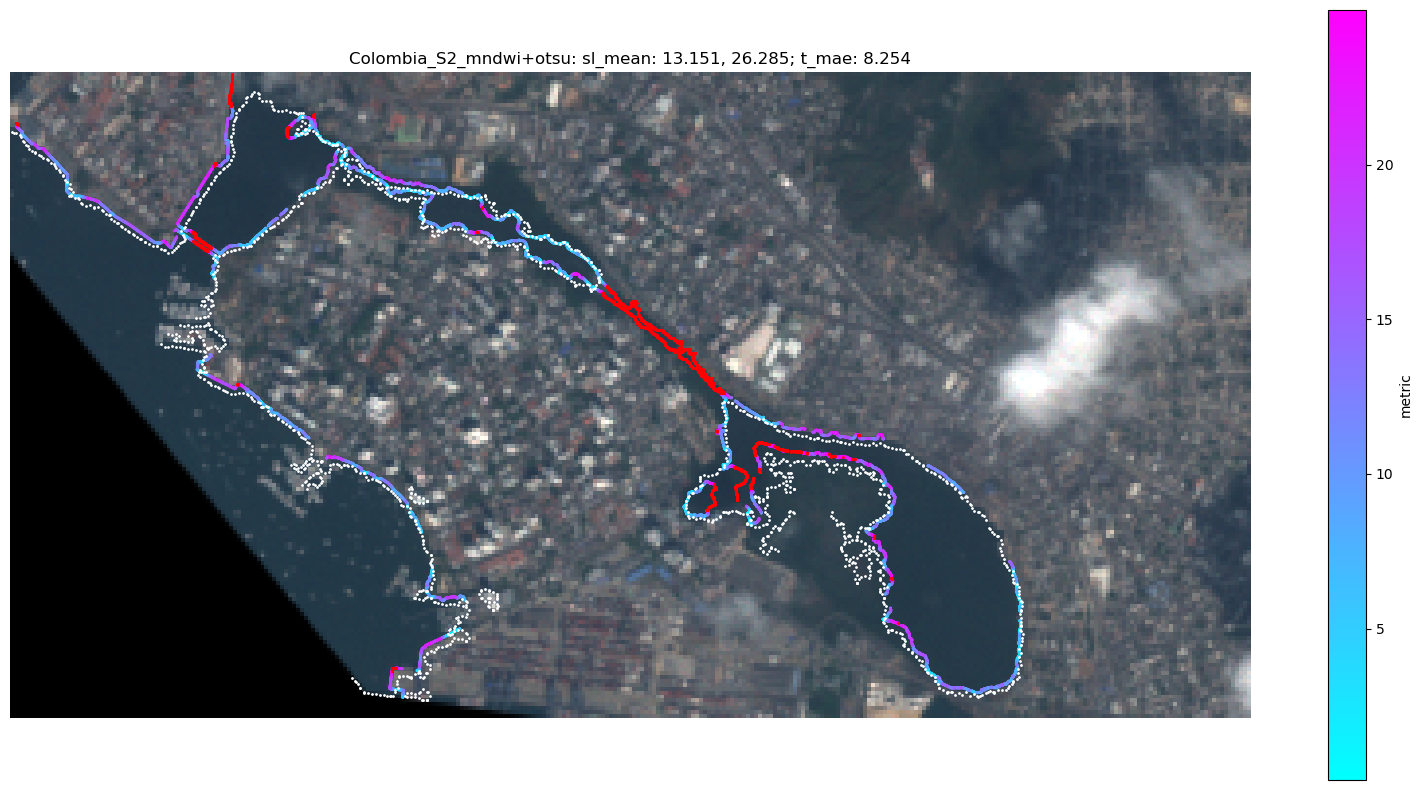

In [28]:
# mndwi + otsu
index = mndwi(sim_bands.reshape(-1, sim_bands.shape[-1]))
threshold = otsu(index, cloud_mask, sds_data["sl_buffer"])
method = "mndwi+otsu"
fig = wvep.plot_method(index, threshold, method, sim_bands, sds_data, ref_sl_points, ref_sl_points_pxl, transects, collider_settings, outlier_idx, georef, sitename, sim_sat)

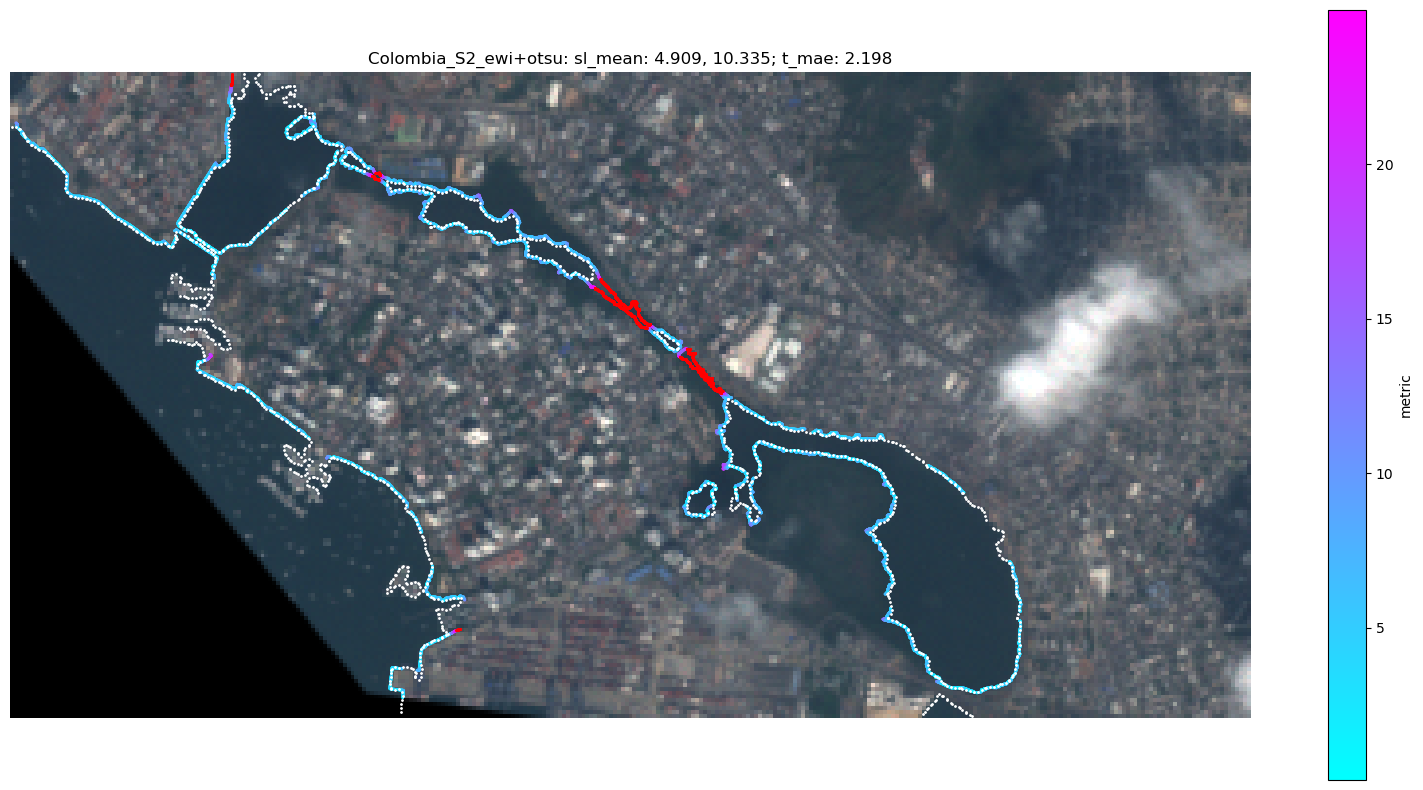

In [29]:
# ewi + otsu
index = ewi(sim_bands.reshape(-1, sim_bands.shape[-1]))
threshold = otsu(index, cloud_mask, sds_data["sl_buffer"])
method = "ewi+otsu"
fig = wvep.plot_method(index, threshold, method, sim_bands, sds_data, ref_sl_points, ref_sl_points_pxl, transects, collider_settings, outlier_idx, georef, sitename, sim_sat)

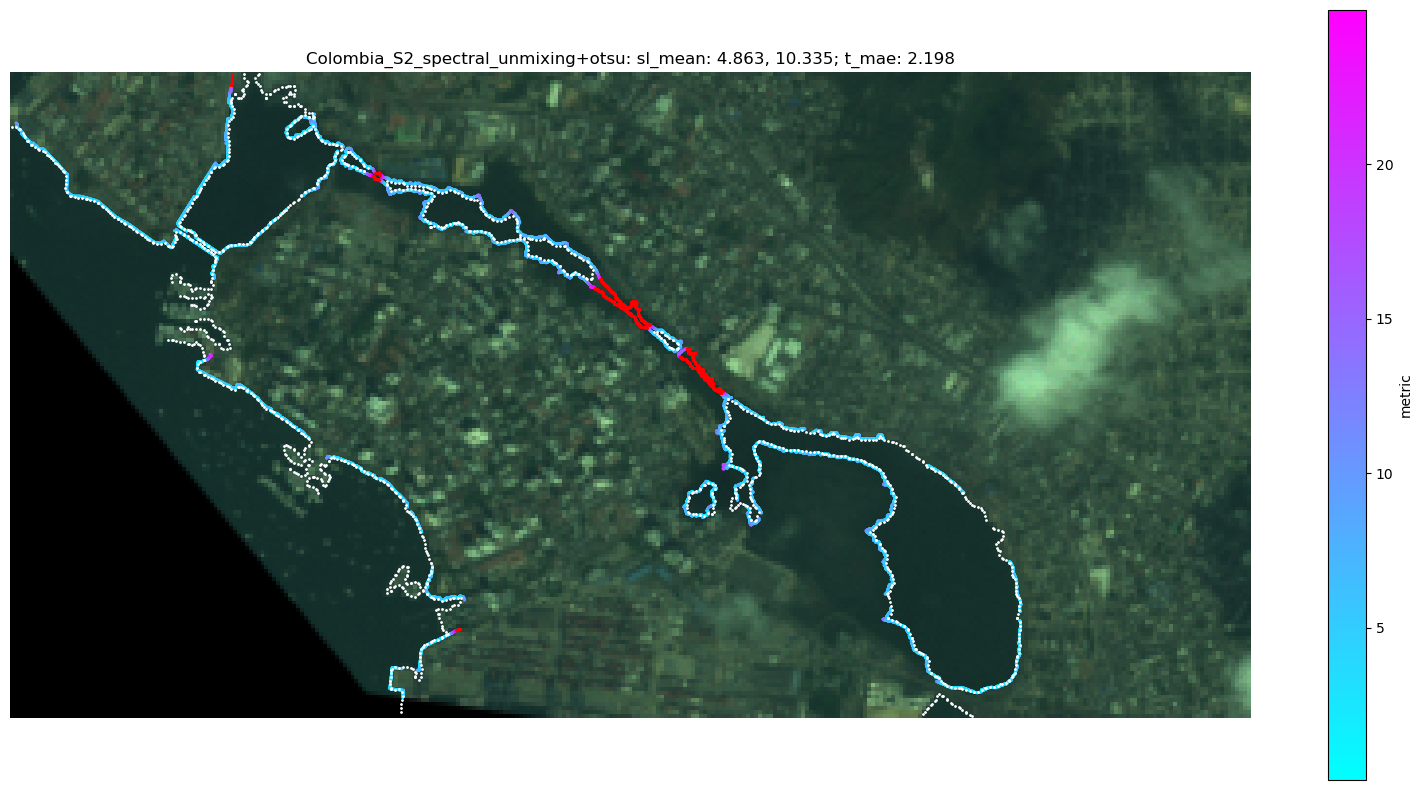

In [89]:
im_ind = ensemble2(sim_bands, ensemble_idx_funcs, otsu, cloud_mask, sds_data["sl_buffer"])
percentages = su.spectral_unmixing_1(sim_bands, im_ind, sds_data)
otsu_thresh = otsu(percentages, cloud_mask, sds_data["sl_buffer"])
method = "spectral_unmixing+otsu"
fig = wvep.plot_method(index, threshold, method, sim_bands, sds_data, ref_sl_points, ref_sl_points_pxl, transects, collider_settings, outlier_idx, georef, sitename, sim_sat)

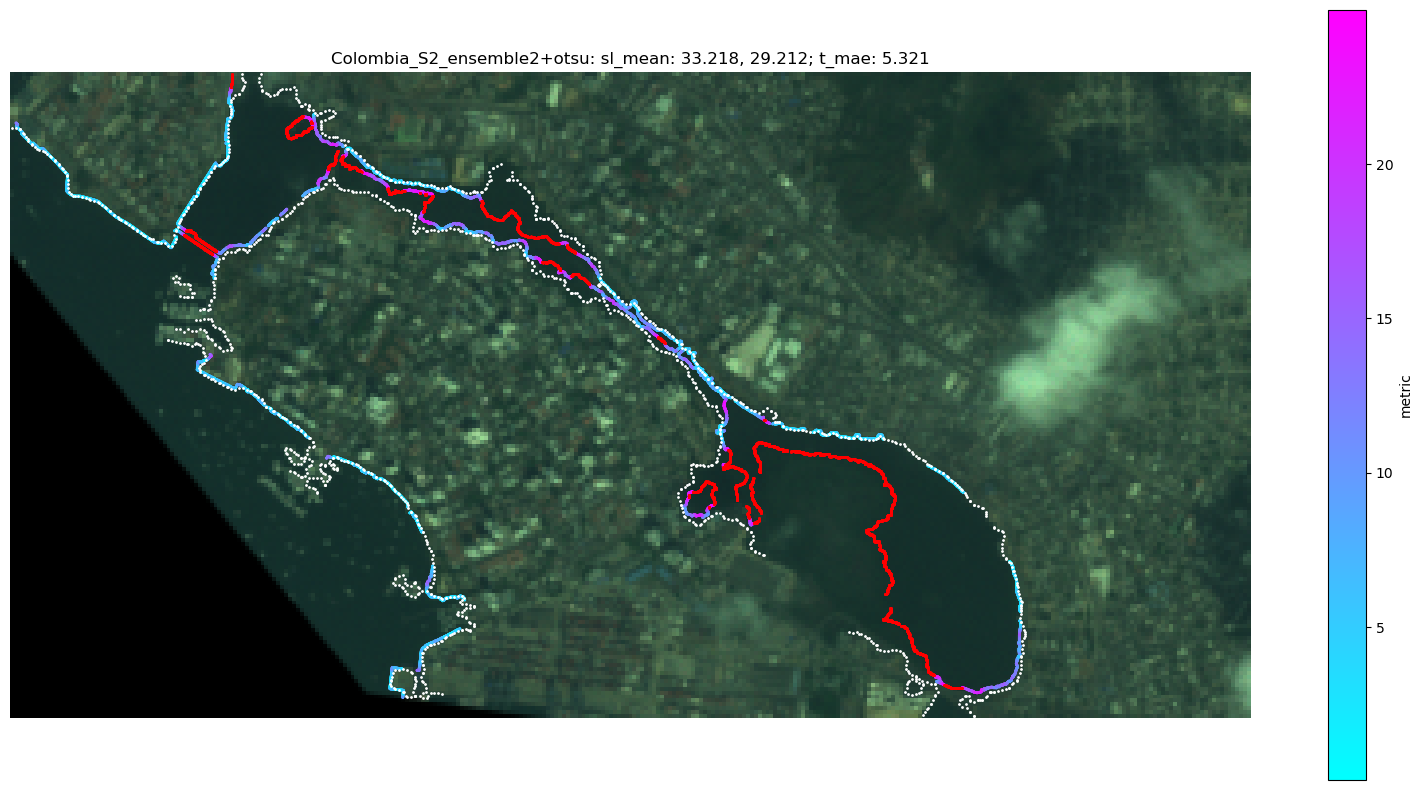

In [ ]:
# tct wetness and otsu
index = tct_wetness(sim_bands.reshape(-1, sim_bands.shape[-1]))
threshold = otsu(index, cloud_mask, sds_data["sl_buffer"])
method = "tct_wetness__otsu"
fig = wvep.plot_method(index, threshold, method, sim_bands, sds_data, ref_sl_points, ref_sl_points_pxl, transects, collider_settings, outlier_idx, georef, sitename, sim_sat)

## Misc Plots

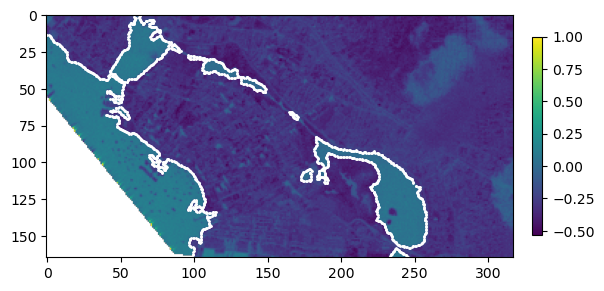

In [79]:
index = ewi(sim_bands.reshape(-1, sim_bands.shape[-1]))
threshold = otsu(index, cloud_mask, sds_data["sl_buffer"])

# fig, ax = plt.subplots(1, 1)
# ax.hist(index, bins=256);
# ax.axvline(threshold)

contours = wv_eval.get_contours(index.reshape(sim_bands.shape[:-1]), threshold, sds_data)
contour_pxl = SDS_tools.convert_world2pix(contours, georef)

fig, ax = plt.subplots()
im = ax.imshow(index.reshape(sim_bands.shape[:-1]))
ax.scatter(contour_pxl[:,0], contour_pxl[:,1], s=1, c="white")
fig.colorbar(im, fraction=0.02, pad=0.04)

0.3850661057692307


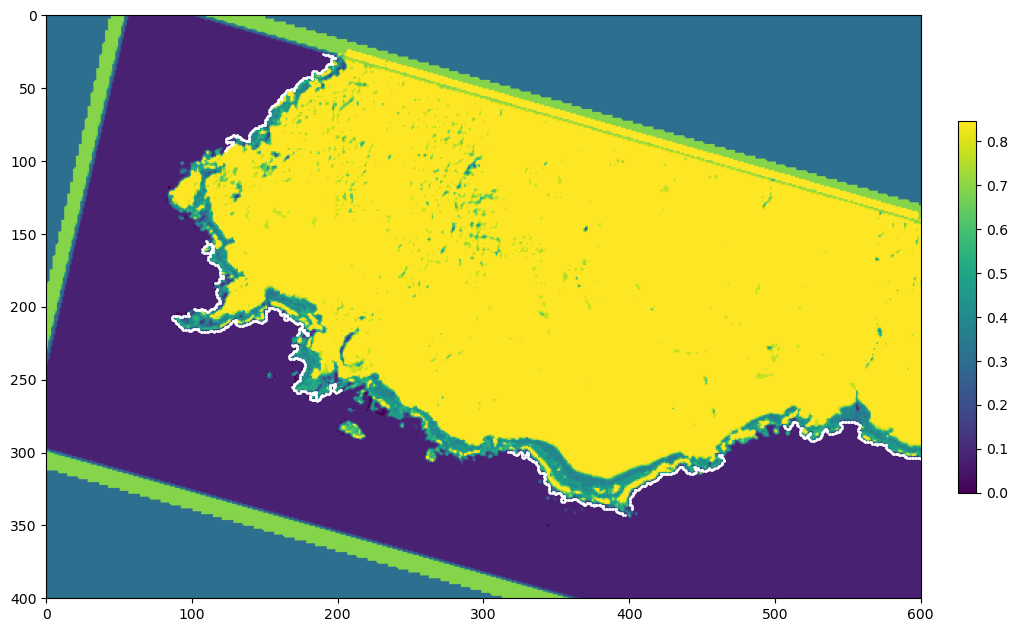

In [117]:
index = ens2(sim_bands, ensemble_idx_funcs, otsu, cloud_mask, sds_data["sl_buffer"])
threshold = otsu(index, cloud_mask, sds_data["sl_buffer"])
print(threshold)
threshold=0.1

contours = wv_eval.get_contours(index.reshape(sim_bands.shape[:-1]), threshold, sds_data)
contour_pxl = modified_coastsat.convert_world2pix(contours, georef)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(index.reshape(sim_bands.shape[:-1]))
ax.scatter(contour_pxl[:,0], contour_pxl[:,1], s=1, c="white")
fig.colorbar(im, fraction=0.02, pad=0.04)
ax.set(xlim=(0,600), ylim=(0,400))
ax.yaxis.set_inverted(True)

sl_mean: 13.818824968799621, 14.235582895635002
t_mae: 8.356192087048338


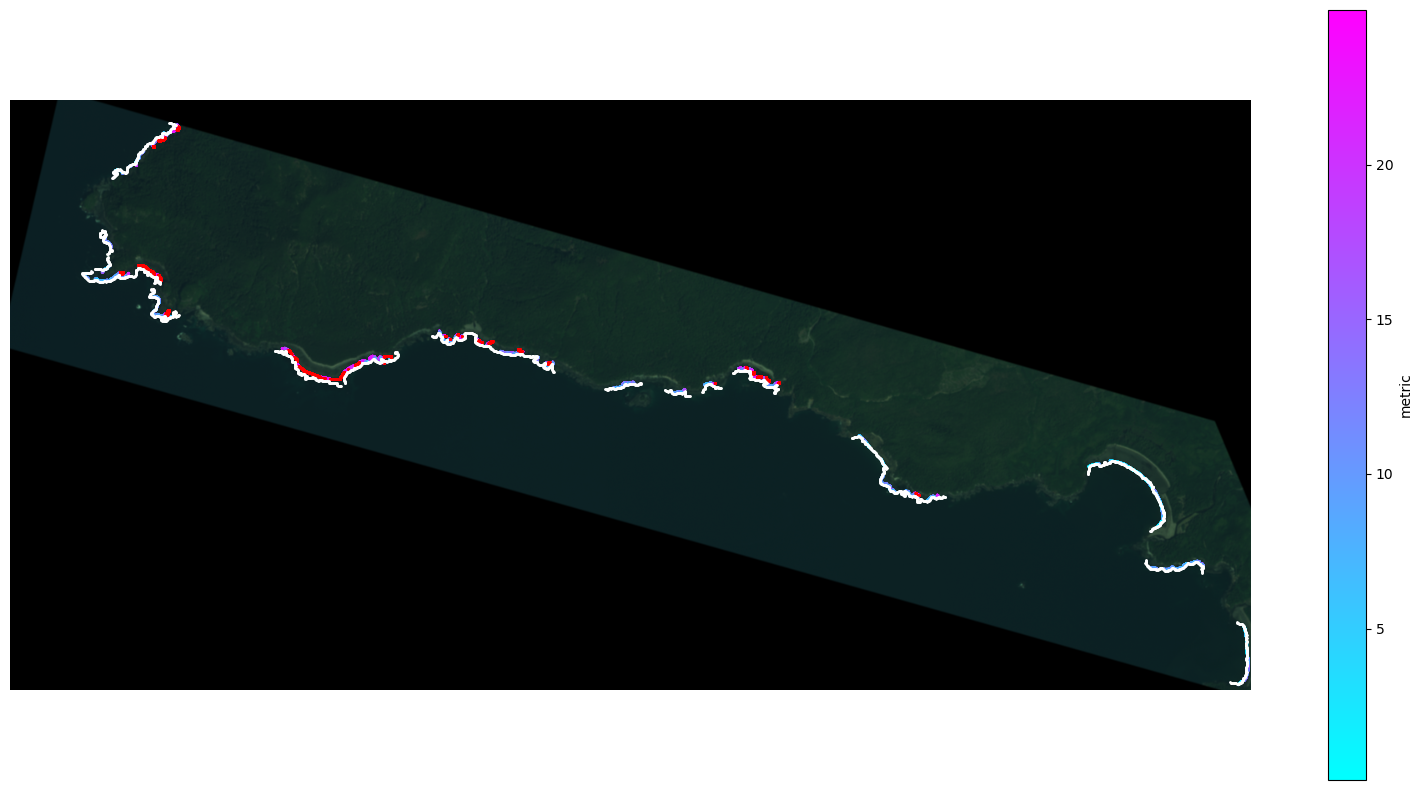

In [119]:
contours = wv_eval.get_contours(index, 0.1, sds_data)
sl_dists = m.get_nearest_distance(ref_sl_points, contours)
t_dists, _ = m.get_median_distances(transects, ref_sl_points, contours, collider_settings)

print(f"sl_mean: {np.mean(sl_dists[~outlier_idx])}, {np.mean(sl_dists)}")
print(f"t_mae: {np.nanmean(np.abs(t_dists))}")
contour_pxl = modified_coastsat.convert_world2pix(contours, georef)
fig = wvep.plot_shoreline_metric(sl_dists, (0, 25), ref_sl_points_pxl, sim_bands[:,:,[2, 1, 0]], contours_pxl=contour_pxl)

sl_mean: 6.513776754025517, 19.62330149244155
t_mae: 10.243643428830785


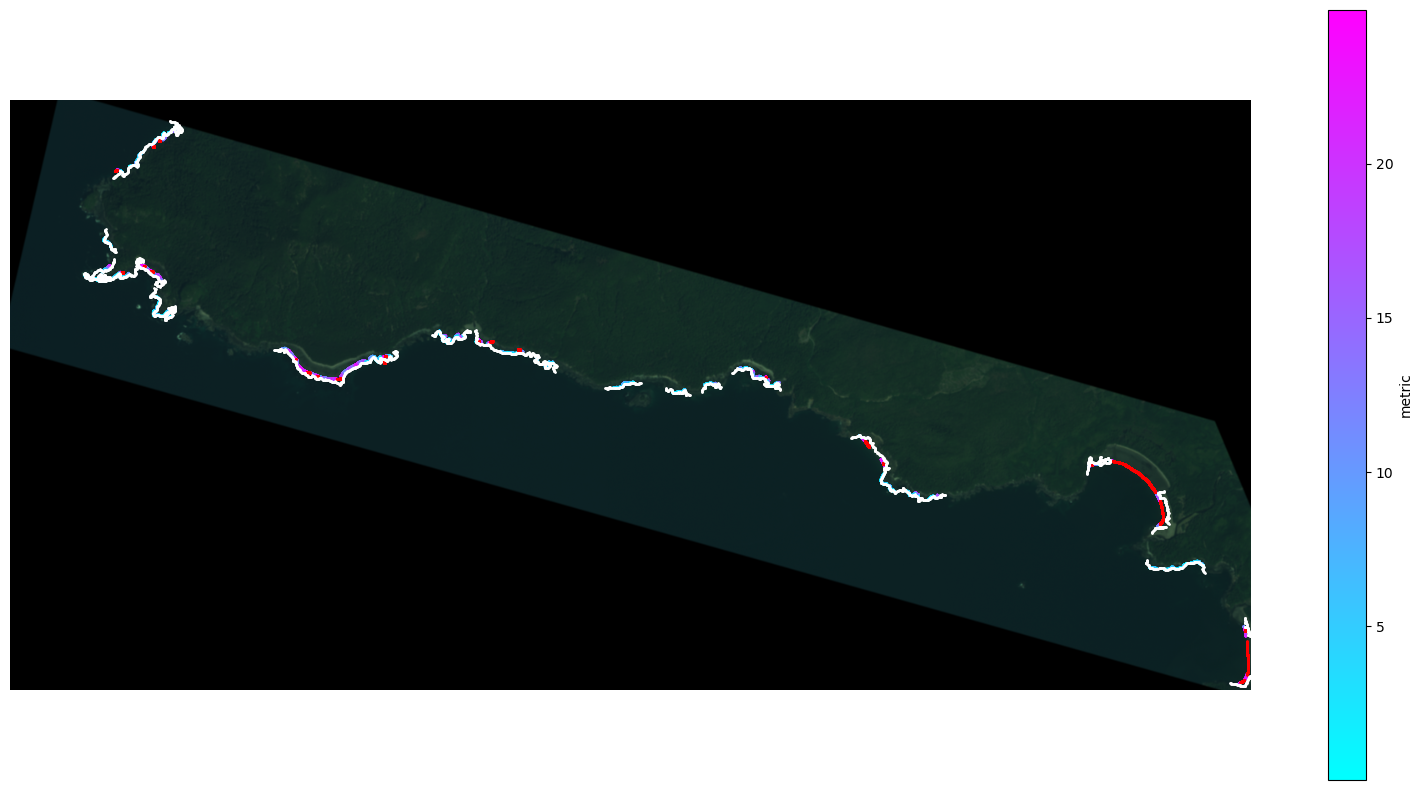

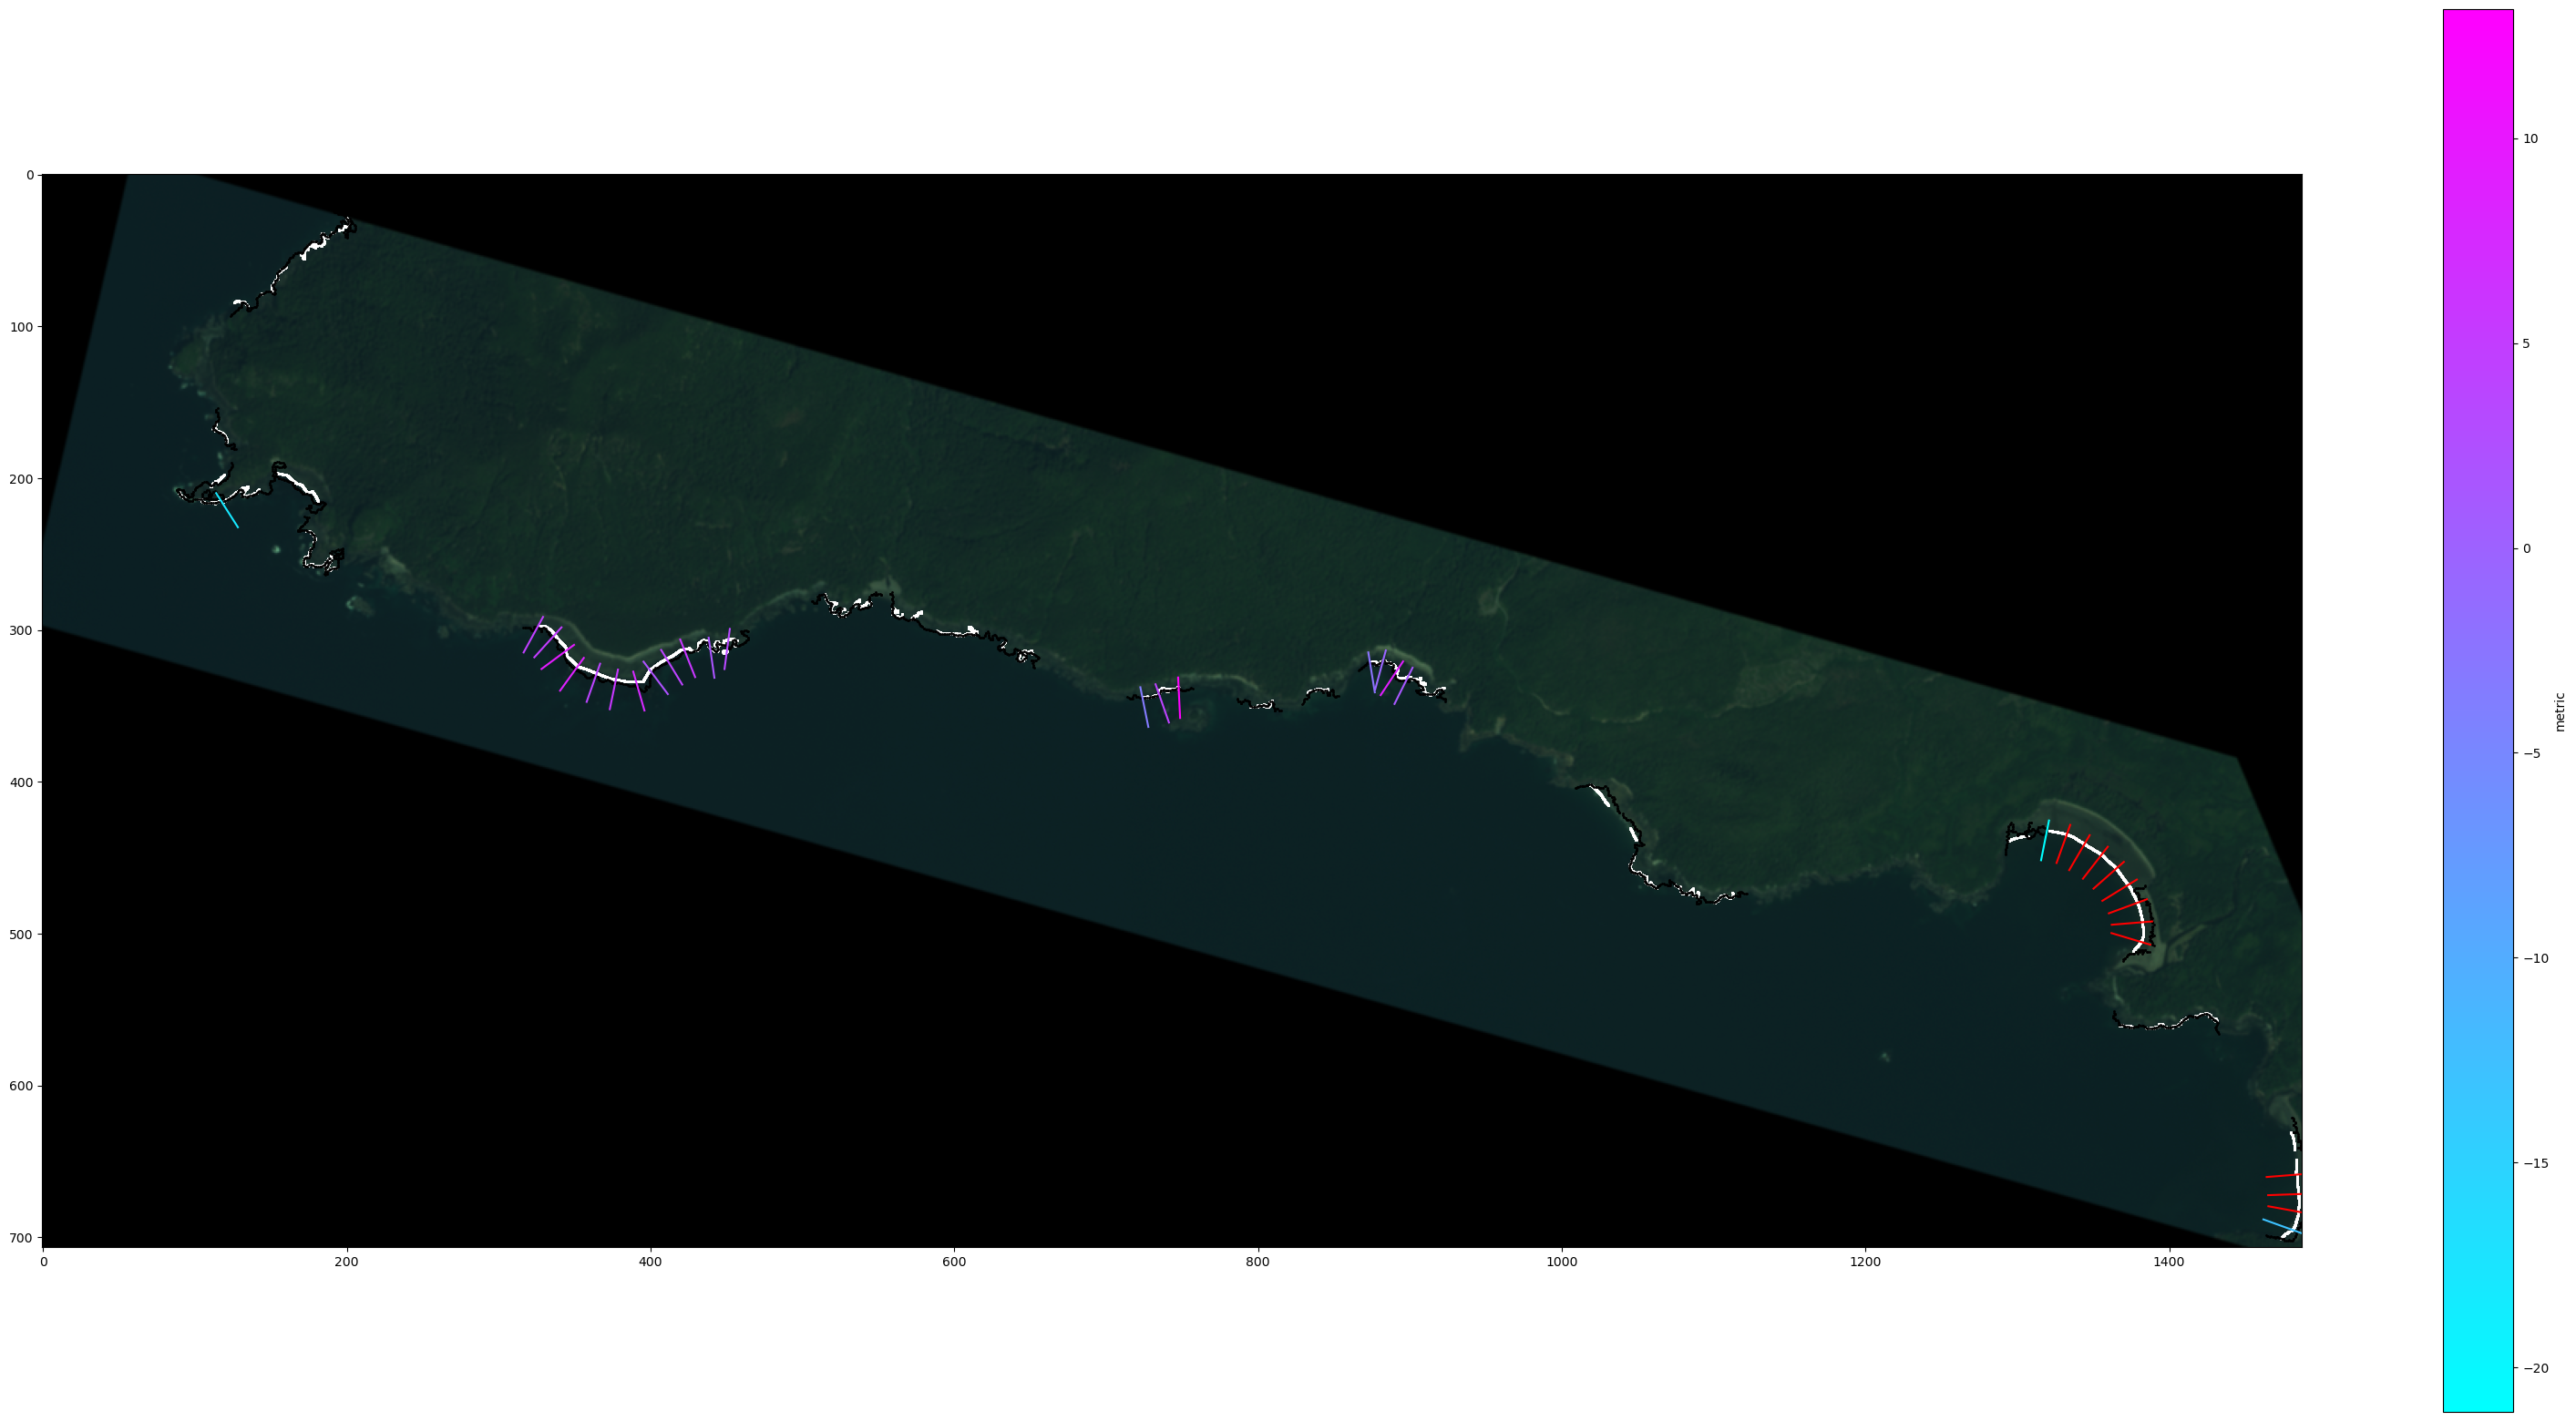

In [ ]:
contours = wv_eval.get_contours(index, 0.38, sds_data)
sl_dists = m.get_nearest_distance(ref_sl_points, contours)
t_dists, _ = m.get_median_distances(transects, ref_sl_points, contours, collider_settings)

print(f"sl_mean: {np.mean(sl_dists[~outlier_idx])}, {np.mean(sl_dists)}")
print(f"t_mae: {np.nanmean(np.abs(t_dists))}")
contour_pxl = modified_coastsat.convert_world2pix(contours, georef)
fig = wvep.plot_shoreline_metric(sl_dists, (0, 25), ref_sl_points_pxl, sim_bands[:,:,[2, 1, 0]], contours_pxl=contour_pxl)